In [1]:
import os
import zipfile
import io
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from typing import Optional, Callable, Tuple

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

PROJECT_DIR = "/content/drive/Shareddrives/DeepLearning_FP/final_project/Our_Project/"

Using device: cuda


## The Dataset

In [3]:
from torchvision import tv_tensors

class FetalEllipseDataset(Dataset):
  """
  Dataset wrapper for the HC18 Fetal Head dataset that extracts ellipse parameters
  directly from ground truth binary masks.

  Parameters:
      images_zip_path: Path to the `_images.zip` file (train or test).
      masks_zip_path: Optional path to the `_masks.zip` file. Pass None for test data.
      transform: Optional torchvision transform applied to the ultrasound image.

  Returns:
      If masks are provided: (image_tensor, ellipse_parameters_tensor)
      If masks are None (Test Mode): (image_tensor, filename_string)
  """
  def __init__(
      self,
      images_zip_path: str,
      masks_zip_path: Optional[str] = None,
      image_transform: Optional[Callable] = None,
      mask_transform: Optional[Callable] = None,
      common_transform: Optional[Callable] = None,
  ) -> None:
      super().__init__()
      self.images_zip_path = images_zip_path
      self.masks_zip_path = masks_zip_path
      self.image_transform = image_transform
      self.mask_transform = mask_transform
      self.common_transform = common_transform

      # Open zip file to read the sorted list of image names
      with zipfile.ZipFile(self.images_zip_path, 'r') as z:
        # Filter out directories if any, keep only image files
        self.image_filenames = sorted([
            f for f in z.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

      # If masks are provided, make sure they align with the image filenames
      if self.masks_zip_path is not None:
        with zipfile.ZipFile(self.masks_zip_path, 'r') as z:
          self.mask_filenames = sorted([
              f for f in z.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))
          ])
          # The num of images has to be the same as the num of masks
          assert len(self.image_filenames) == len(self.mask_filenames), \
              f"Mismatch: Found {len(self.image_filenames)} images but {len(self.mask_filenames)} masks."

  def _extract_ellipse_parameters(self, mask: np.ndarray | torch.Tensor) -> np.ndarray:
    """
    Parses a mask from bytes, finds its outer contour, fits an ellipse,
    and returns the 6 key parameters: [Xc, Yc, d_max, d_min, sin2theta, cos2theta].
    """
    # Convert tensor to numpy:
    if isinstance(mask, torch.Tensor):
      mask = mask.detach().cpu().numpy()
    # if shape is (1, H, W), squeeze channel
    if mask.ndim == 3:
      mask = mask.squeeze()

    # Ensure uint8 binary image
    mask = (mask > 0).astype(np.uint8) * 255

    height, width = mask.shape[:2]

    # Threshold just to be safe (ensure binary 0 or 255)
    # any value below 127 becomes 0 (black), 255 (white) otherwise.
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
      # Fallback if a mask is completely blank (all black)
      return np.zeros(6, dtype=np.float32)

    # Get the largest contour (the fetal head boundary), discard any other possible noise.
    largest_contour = max(contours, key=cv2.contourArea)

    # cv2.fitEllipse requires at least 5 points to mathematically calculate the ellipse
    if len(largest_contour) >= 5:
      (xc, yc), (dmin, dmax), theta = cv2.fitEllipse(largest_contour)
    else:
      # Fallback using a bounding box if contour has too few points-> if it has not more than 5 points
      x, y, w, h = cv2.boundingRect(largest_contour)
      xc, yc, dmax, dmin, theta = x + w/2, y + h/2, float(max(w, h)), float(min(w, h)), 0.0

    # NORMALIZATION OF THE PARAMETERS:

    xc_norm = xc/width            # [0, 1]
    yc_norm = yc / height         # [0, 1]
    dmax_norm = dmax / width      # [0, 1]
    dmin_norm = dmin / height     # [0, 1]

    theta_rad = np.radians(theta)
    # We need to multiply theta by 2 because the rotatoin period of an ellipse is 180º
    sin_2theta = np.sin(2 * theta_rad)
    cos_2theta = np.cos(2 * theta_rad)

    return np.array([xc_norm, yc_norm, dmax_norm, dmin_norm, sin_2theta, cos_2theta], dtype=np.float32)

  def __getitem__(self, index: int) -> Tuple[torch.Tensor, any]:
    img_name = self.image_filenames[index]

    # Read image directly out of the zip archive without extracting to disk
    with zipfile.ZipFile(self.images_zip_path, 'r') as z_img:
      img_bytes = z_img.read(img_name)
      image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    # Apply image transformations (Resize, ToTensor, Normalize, etc.)
    if self.image_transform is not None:
      image = self.image_transform(image)

    # If we are working with training data, process the mask vector
    if self.masks_zip_path is not None:
      mask_name = self.mask_filenames[index]
      with zipfile.ZipFile(self.masks_zip_path, 'r') as z_mask:
        mask_bytes = z_mask.read(mask_name)
        original_mask = Image.open(io.BytesIO(mask_bytes)).convert("L")

      if self.mask_transform is not None and original_mask is not None:
        original_mask = self.mask_transform(original_mask)
        if self.common_transform is not None:
          image = tv_tensors.Image(image) # BILINEAR
          original_mask = tv_tensors.Mask(original_mask) # NEAREST
          image, original_mask = self.common_transform(image, original_mask) # e.g. common rotation

      original_mask_np = np.array(original_mask, dtype=np.uint8) # needed for _extract_ellipse_parameters

      ellipse_params = self._extract_ellipse_parameters(original_mask_np)
      # Convert parameters to a PyTorch float tensor
      target = torch.tensor(ellipse_params, dtype=torch.float32)

      return image, target, original_mask

    # If we are in test mode (no masks), return the image and its filename
    return image, img_name, None

  def __len__(self) -> int:
    return len(self.image_filenames)

In [4]:
import torchvision.transforms as tf
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import torchvision.transforms.v2 as tfv2

# 1. Paths matching your 'data' folder structure
DATA_DIR = os.path.join(PROJECT_DIR, "data")
TRAIN_IMAGES_ZIP = os.path.join(DATA_DIR, "train_images.zip")
TRAIN_MASKS_ZIP = os.path.join(DATA_DIR, "train_masks.zip")
TEST_IMAGES_ZIP = os.path.join(DATA_DIR, "test_images.zip")
TEST_MASK_ZIP = os.path.join(DATA_DIR, "test_masks.zip")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# 2. Set up image transformations

# COMMON TRANSFORMATIONS

# common_transforms = tfv2.Compose([ # it allows tensors (PILImage is no necessary)
#     #tfv2.RandomResizedCrop(size=(256, 256), scale=(0.75, 1.0), ratio=(1.0, 1.0)),
#     tfv2.RandomRotation(degrees=20),
#     tfv2.RandomHorizontalFlip(p=0.5),
#     tfv2.RandomVerticalFlip(p=0.1),
# ])

common_transforms = tfv2.Compose([
    tfv2.RandomRotation(
        degrees=15,
        interpolation=tfv2.InterpolationMode.BILINEAR
    ),
    tfv2.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),  # ±10%
        scale=(0.9, 1.1),        # zoom
        interpolation=tfv2.InterpolationMode.BILINEAR
    ),
])

# WITHOUT DATA AUGMENTATION
img_transforms = tf.Compose([
    tf.Resize((256, 256)), # default bilinear interpolation
    tf.ToTensor(),
    # tf.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet
    tf.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0])
])

mask_transforms = tf.Compose([
    tf.Resize((256, 256)), # default bilinear interpolation
    tf.ToTensor(),
])

# WITH DATA AUGMENTATION
img_transforms_da = tf.Compose([
    tf.Resize((256, 256)), # default bilinear interpolation
    tf.ColorJitter(brightness=0.2, contrast=0.2),
    tf.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    tf.ToTensor(),
    # tf.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet
    tf.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0])
])

mask_transforms_da = tf.Compose([
    tf.Resize((256, 256), tf.InterpolationMode.NEAREST), # for mask NEAREST
    tf.ToTensor(),
])

# 3. Instantiate the full training dataset
full_train_dataset = FetalEllipseDataset(
    images_zip_path=TRAIN_IMAGES_ZIP,
    masks_zip_path=TRAIN_MASKS_ZIP,
    # We will apply transforms later via TransformedSubset
)

# 4. Generate a Train/Validation split (80/20)
all_indices = list(range(len(full_train_dataset)))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)

train_subset = Subset(full_train_dataset, train_indices)
val_subset = Subset(full_train_dataset, val_indices)

In [ ]:
# Load the full test dataset without mini batches
test_dataset = FetalEllipseDataset(
    images_zip_path=TEST_IMAGES_ZIP,
    masks_zip_path=TEST_MASK_ZIP,
    # NO transformations
)

In [5]:
class TransformedSubset(Dataset):
  """
  Apply a transform to samples retrieved from a dataset subset.

  Parameters:
      subset: Dataset subset that returns PIL images and labels.
      transform: Transform applied to the image.

  Returns:
      Dataset yielding transformed image-label pairs.
  """

  def __init__(
      self,
      subset: Dataset,
      image_transform: Optional[Callable],
      mask_transform: Optional[Callable],
      common_transform: Optional[Callable] = None,
  ) -> None:

    self.subset = subset
    self.image_transform = image_transform
    self.mask_transform = mask_transform
    self.common_transform = common_transform

  def __getitem__(self, index: int) -> Tuple[torch.Tensor, any]:
    """
    Retrieve one transformed sample.
    """
    image, target, original_mask = self.subset[index]

    if self.image_transform is not None:
      image = self.image_transform(image)

    if self.mask_transform is not None and original_mask is not None:
      original_mask = self.mask_transform(original_mask)
      if self.common_transform is not None:
        image = tv_tensors.Image(image) # BILINEAR
        original_mask = tv_tensors.Mask(original_mask) # NEAREST
        image, original_mask = self.common_transform(image, original_mask) # e.g. common rotation

      original_mask_np = np.array(original_mask, dtype=np.uint8) # needed for _extract_ellipse_parameters

      ellipse_params = self.subset.dataset._extract_ellipse_parameters(original_mask_np)
      # Convert parameters to a PyTorch float tensor
      target = torch.tensor(ellipse_params, dtype=torch.float32)

    return image, target, original_mask

  def __len__(self) -> int:
    """
    Return the number of samples in the subset.
    """
    return len(self.subset)

In [6]:
train_loader = DataLoader(
    TransformedSubset(train_subset, img_transforms, mask_transforms),
    batch_size=16, # Regression takes less memory, but lower batch sizes yield more stable gradients
    shuffle=True,
    num_workers=0
)

train_loader_da = DataLoader(
    TransformedSubset(train_subset, img_transforms_da, mask_transforms_da, common_transforms),
    batch_size=16, # Regression takes less memory, but lower batch sizes yield more stable gradients
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    TransformedSubset(val_subset, img_transforms, mask_transforms),
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    FetalEllipseDataset(images_zip_path=TEST_IMAGES_ZIP, masks_zip_path=TEST_MASK_ZIP, image_transform=img_transforms, mask_transform=mask_transforms),
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [7]:
print("-- SHAPES OF THE DATASET --")
print("Length of the full training dataset:", len(full_train_dataset))
print("Length of training dataset after split :", len(train_subset))
print("Length of validation dataset after split :", len(val_subset))
print("Length of test set:", len(test_loader.dataset))

-- SHAPES OF THE DATASET --
Length of the full training dataset: 799
Length of training dataset after split : 639
Length of validation dataset after split : 160
Length of test set: 200


In [8]:
def denormalize_ellipse_parameters(target, width, height):
  xc_norm, yc_norm, dmax_norm, dmin_norm, sin_2theta, cos_2theta = target.tolist()
  # Denormalize spatial parameters
  xc = xc_norm * width
  yc = yc_norm * height
  dmax = dmax_norm * width
  dmin = dmin_norm * height

  # Recover the angle
  two_theta_rad = np.arctan2(sin_2theta, cos_2theta)
  theta = np.degrees(two_theta_rad / 2.0)

  if theta < 0:
    theta += 180.0

  return xc, yc, dmax, dmin, theta

In [9]:
def denormalize_image(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
  # 1. Reshape mean and std to (C, 1, 1) for broadcasting
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    # 2. Invert the normalization: (img * std) + mean
    denorm_img = image * std + mean

    # 3. Clamp values to strict [0, 1] range
    denorm_img = torch.clamp(denorm_img, 0, 1)

    # 4. Rearrange to (H, W, C) for standard image formatting
    denorm_img = denorm_img.permute(1, 2, 0)

    # 5. Convert to NumPy array (and move to CPU if it was on a GPU)
    return denorm_img.cpu().numpy()

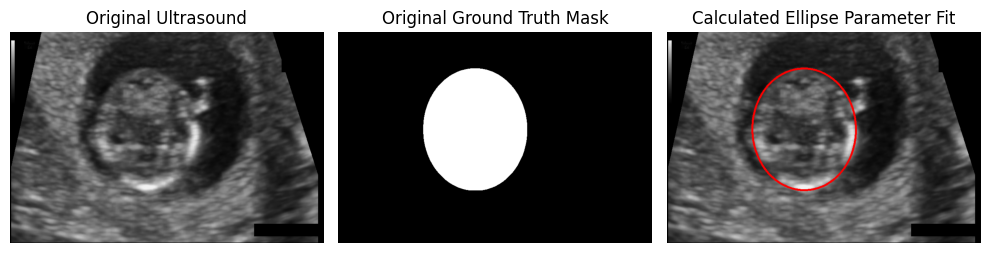

In [10]:
import matplotlib.pyplot as plt

first_image, first_target, first_mask = full_train_dataset[10]

# convert PIL image to NumPy array so OpenCV can draw on it
image_np = np.array(first_image)
# get the 5 ellipse parameters
# xc, yc, dmax, dmin, sin_2theta, cos_2theta = first_target.tolist()
xc, yc, dmax, dmin, theta = denormalize_ellipse_parameters(first_target, image_np.shape[1],  image_np.shape[0])

# matplotlib is not relative to the y-axis.
theta += 90

ellipse_image = image_np.copy()

# 5. Draw the ellipse using OpenCV
# Arguments: image, (center_x, center_y), (axes_half_lengths), angle, start_angle, end_angle, color, thickness
cv2.ellipse(
    ellipse_image,
    (int(xc), int(yc)),
    (int(dmax / 2), int(dmin / 2)), # OpenCV expects half-lengths (radii)
    int(theta),
    0, 360,                        # Draw a full 360-degree ellipse
    (255, 0, 0),                   # Color: Red (assuming RGB format from PIL)
    3                              # Thickness of the line in pixels
)

# 6. Plot side-by-side using Matplotlib
plt.figure(figsize=(10, 5))

# Left: Original Ultrasound
plt.subplot(1, 3, 1)
plt.title("Original Ultrasound")
plt.imshow(image_np)
plt.axis('off')

# Middle: Ground Truth Binary Mask
plt.subplot(1, 3, 2)
plt.title("Original Ground Truth Mask")
plt.imshow(first_mask, cmap='gray')
plt.axis('off')

# Right: Ellipse Fit Overlay
plt.subplot(1, 3, 3)
plt.title("Calculated Ellipse Parameter Fit")
plt.imshow(ellipse_image)
plt.axis('off')

plt.tight_layout()
plt.show()


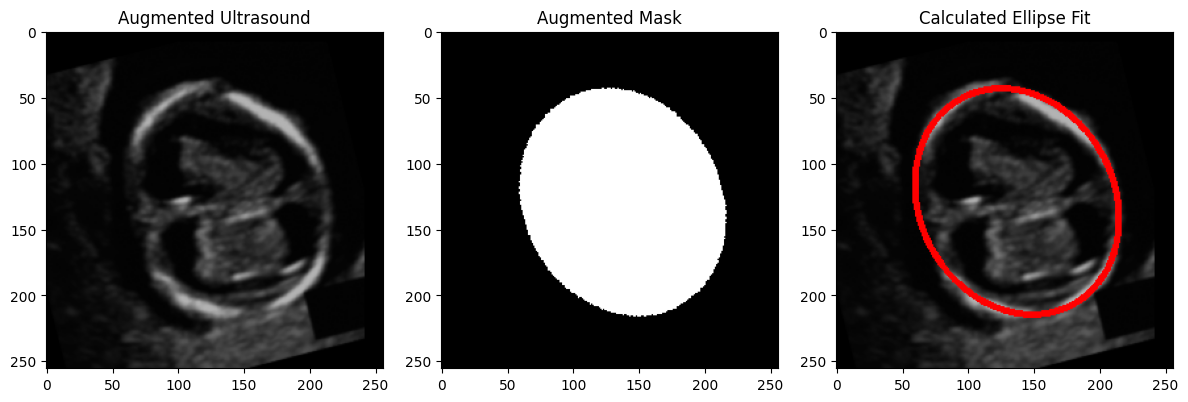

In [11]:
# 1. Grab the dataset from train_loader or train_loader_da:
dataset = train_loader_da.dataset

idx = np.random.randint(0, len(dataset))
# 2. Extract a random sample from the da dataset
image_tensor, target_tensor, mask_tensor = dataset[idx]

# Convert image tensor (C, H, W) to numpy array (H, W, C) scaled to [0, 255]
image_np = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8) #denormalize_image(image_tensor)

# 4. Convert mask tensor (C, H, W) to grayscale numpy array (H, W)
# Squeeze out the channel dimension since it's grayscale (1, H, W -> H, W)
mask_np = (mask_tensor.squeeze().cpu().numpy() * 255).astype(np.uint8)


# 5. Denormalize your target parameters using your custom function
# targets_batch yields targets as tensors; convert the first one to list/numpy
xc, yc, dmax, dmin, theta = denormalize_ellipse_parameters(
    target_tensor.cpu().numpy(),
    image_np.shape[1],
    image_np.shape[0]
)

# Adjust for matplotlib/OpenCV relative to y-axis if required by your script
theta += 90

ellipse_image = image_np.copy()

# 6. Draw the ellipse using OpenCV
cv2.ellipse(
    ellipse_image,
    (int(xc), int(yc)),
    (int(dmax / 2), int(dmin / 2)),
    int(theta),
    0, 360,
    (255, 0, 0), # Red
    3
)

plt.figure(figsize=(12, 5))

# Left: Augmented Ultrasound
plt.subplot(1, 3, 1)
plt.title("Augmented Ultrasound")
plt.imshow(image_np)
plt.axis('on')

# Middle: Augmented Ground Truth Binary Mask
plt.subplot(1, 3, 2)
plt.title("Augmented Mask")
plt.imshow(mask_np, cmap='gray')
plt.axis('on')

# Right: Ellipse Fit Overlay on Augmented Image
plt.subplot(1, 3, 3)
plt.title("Calculated Ellipse Fit")
plt.imshow(ellipse_image)
plt.axis('on')

plt.tight_layout()
plt.show()

## MobileNet v3 model

In [12]:
import torch
import torch.nn as nn
import torchvision.models as models

class EllipseNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = models.mobilenet_v3_small(
            weights="DEFAULT"
        )

        in_features = self.backbone.classifier[-1].in_features

        # substitute the classifier
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128), # from 1024 to 576
            nn.Hardswish(),
            nn.Dropout(0.2),

            # output:
            # cx, cy, a, b, theta (decomposed in sin(2theta) and cos(2theta))
            nn.Linear(128, 6)
        )

    def forward(self, x):
        return self.backbone(x)


In [13]:
from typing import Tuple, List
import time
import torch
import torch.nn as nn
import torch.optim as optim

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):

    model.train()
    model.to(device)

    total_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    for images, labels, _ in dataloader: # ultrasound image, 5 params, mask (not needed)
        images = images.to(device)
        labels = labels.float().to(device)  # ellipse parameters

        outputs = model(images)  # Forward pass: [B, 5] where B is batch size

        loss = criterion(outputs, labels) # mean of 16x5 = 80 loss values

        optimizer.zero_grad() # clear gradients from previous batch
        loss.backward() # backpropagation
        optimizer.step() # update weights

        # We undo the mean and just accumulate the sum of losses
        # because the last batch_size can be < 16. At the end we will compute the mean.
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size # undo the mean

        # MAE metric (interpretable)
        mae = torch.abs(outputs - labels).mean().item()
        total_mae += mae * batch_size

        total_samples += batch_size

# we have prevented a smaller last batch from having an unfair,
#disproportionate impact on your overall epoch metrics.
    avg_loss = total_loss / total_samples
    avg_mae = total_mae / total_samples

    return avg_loss, avg_mae

def val_step(model: nn.Module,
             dataloader: torch.utils.data.DataLoader,
             criterion: nn.Module,
             device: torch.device):

    model.eval()
    model.to(device)

    total_loss = 0.0
    total_mae = 0.0
    total_samples = 0

    with torch.inference_mode(): # Disable gradient computation
        for images, labels, _ in dataloader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images) # Forward pass

            loss = criterion(outputs, labels) # Compute loss

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size

            mae = torch.abs(outputs - labels).mean().item()
            total_mae += mae * batch_size

            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_mae = total_mae / total_samples

    return avg_loss, avg_mae

def train(model: nn.Module,
          train_loader: torch.utils.data.DataLoader,
          val_loader: torch.utils.data.DataLoader,
          criterion: nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          num_epochs: int = 10,
          model_name: str = "best_model.pt",
          results_path: str = "."):

    model.to(device)

    best_val_loss = float("inf")

    train_losses, train_maes = [], []
    val_losses, val_maes = [], []

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_mae = train_step(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_mae = val_step(
            model, val_loader, criterion, device
        )

        train_losses.append(train_loss)
        train_maes.append(train_mae)
        val_losses.append(val_loss)
        val_maes.append(val_mae)

        elapsed = time.time() - start_time
        mins, secs = divmod(elapsed, 60)

        print(f"Epoch {epoch+1}")
        print(
            f"Train Loss: {train_loss:.5f} | Train MAE: {train_mae:.5f} | "
            f"Val Loss: {val_loss:.5f} | Val MAE: {val_mae:.5f} | "
            f"Time: {int(mins)}m {secs:.2f}s\n"
        )

        # save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                model.state_dict(),
                os.path.join(results_path, model_name)
            )

    return train_losses, train_maes, val_losses, val_maes


In [14]:
def plot_train_vs_val_loss_mae(losses_list, title=None):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

  if title:
    fig.suptitle(title, fontsize=16, fontweight='bold')

  ax1.plot(losses_list[0], label="Train Loss", color="blue")      # train_losses
  ax1.plot(losses_list[2], label="Validation Loss", color="orange") # validation losses
  ax1.set_title("Loss Curves")
  ax1.set_xlabel("Epoch")
  ax1.set_ylabel("Loss")
  ax1.legend()

  ax2.plot(losses_list[1], label="Train MAE", color="blue")      # train MAE
  ax2.plot(losses_list[3], label="Validation MAE", color="orange") # validation MAE
  ax2.set_title("MAE Curves")
  ax2.set_xlabel("Epoch")
  ax2.set_ylabel("Accuracy")
  ax2.legend()

  plt.tight_layout()
  plt.show()

## Transfer Learning and Training of the Linear Classifier

In [26]:
model = EllipseNet()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 125MB/s]


In [27]:
# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier only
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

In [ ]:
# Define the loss function
criterion = nn.SmoothL1Loss()

# Define the learning rate
learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr = learning_rate)

model = model.to(device)

print("--- Training only the Classifier of EllipseNet w/o Data Augmentation ---")

losses_list = train(model, train_loader, val_loader, criterion, optimizer, device=device, num_epochs=15, model_name='train_classifier_only_model.pt',  results_path=RESULTS_DIR)


--- Training only the Classifier of EllipseNet w/o Data Augmentation ---
Epoch 1
Train Loss: 0.03020 | Train MAE: 0.17912 | Val Loss: 0.02886 | Val MAE: 0.18617 | Time: 11m 14.93s

Epoch 2
Train Loss: 0.01595 | Train MAE: 0.12135 | Val Loss: 0.02113 | Val MAE: 0.13618 | Time: 0m 25.68s

Epoch 3
Train Loss: 0.01430 | Train MAE: 0.11313 | Val Loss: 0.02701 | Val MAE: 0.14037 | Time: 0m 24.74s

Epoch 4
Train Loss: 0.01411 | Train MAE: 0.11023 | Val Loss: 0.01648 | Val MAE: 0.11516 | Time: 0m 26.04s

Epoch 5
Train Loss: 0.01310 | Train MAE: 0.10606 | Val Loss: 0.02173 | Val MAE: 0.13113 | Time: 0m 26.12s

Epoch 6
Train Loss: 0.01270 | Train MAE: 0.10457 | Val Loss: 0.02131 | Val MAE: 0.12039 | Time: 0m 25.68s

Epoch 7
Train Loss: 0.01198 | Train MAE: 0.09959 | Val Loss: 0.01847 | Val MAE: 0.10972 | Time: 0m 25.87s

Epoch 8
Train Loss: 0.01247 | Train MAE: 0.10146 | Val Loss: 0.01597 | Val MAE: 0.10433 | Time: 0m 23.90s

Epoch 9
Train Loss: 0.01224 | Train MAE: 0.10133 | Val Loss: 0.01856 |

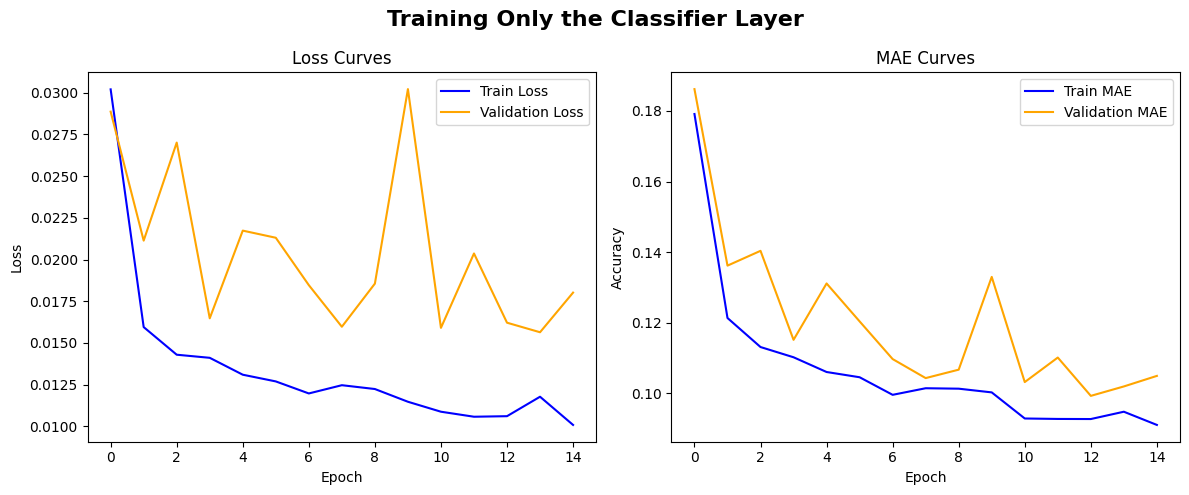

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training Only the Classifier Layer")

# Load and Evaluate the model with the test dataset

In [ ]:
# Load the trained model -> train_classifier_only_model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "train_classifier_only_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae = val_step(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print("--- model's performance on test set ---")
print(f"Average Loss:{avg_test_loss:.4f}")
print(f"Average MAE:{avg_test_mae:.2f}")

--- model's performance on test set ---
Average Loss:0.0153
Average MAE:0.10


In [15]:
def plot_predictions_vs_gt(model_to_eval, test_set, NUM_SAMPLES = 5):

  #1. Get some random indices
  random_indices = np.random.randint(0, len(test_set.dataset), size=NUM_SAMPLES)

  for sample_idx in random_indices:

    #2. Sample the random element from the test_loader
    raw_image, ground_truth_target, raw_mask = test_set.dataset[sample_idx]

    input_tensor = raw_image.unsqueeze(0).to(device)  # Add batch dimension [1, C, H, W]
    image_np = denormalize_image(raw_image, mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0]) #np.array(raw_image.cpu().permute(1, 2, 0).numpy())
    height, width = image_np.shape[:2]

    # 3. Get the prediction from your trained model
    with torch.no_grad():
        predicted_target = model_to_eval(input_tensor)
        # Move back to CPU, remove batch dimension, and convert to list
        predicted_target = predicted_target.squeeze(0).cpu().numpy()

    # 4. Extract Ground Truth parameters
    gt_xc, gt_yc, gt_dmax, gt_dmin, gt_theta = denormalize_ellipse_parameters(ground_truth_target.squeeze(0).cpu().numpy(), width, height)
    gt_theta += 90
    print("Ground Truth Parameters:", gt_xc,"-", gt_yc,"-", gt_dmax,"-", gt_dmin,"-", gt_theta)

    # 5. Extract Predicted parameters
    pred_xc, pred_yc, pred_dmax, pred_dmin, pred_theta = denormalize_ellipse_parameters(predicted_target, width, height)
    pred_theta += 90
    print("Predicted Parameters:", pred_xc,"-", pred_yc,"-", pred_dmax,"-", pred_dmin,"-", pred_theta)

    ellipse_image = image_np.copy()

    # 5. Draw the ellipse using OpenCV
    # Arguments: image, (center_x, center_y), (axes_half_lengths), angle, start_angle, end_angle, color, thickness
    cv2.ellipse(
        ellipse_image,
        (int(gt_xc), int(gt_yc)),
        (int(gt_dmax / 2), int(gt_dmin / 2)), # OpenCV expects half-lengths (radii)
        int(gt_theta),
        0, 360,                        # Draw a full 360-degree ellipse
        (255, 0, 0),                   # Color: Red (assuming RGB format from PIL)
        10                              # Thickness of the line in pixels
    )

    cv2.ellipse(
        ellipse_image,
        (int(pred_xc), int(pred_yc)),
        (int(pred_dmax / 2), int(pred_dmin / 2)), # OpenCV expects half-lengths (radii)
        int(pred_theta),
        0, 360,                        # Draw a full 360-degree ellipse
        (0, 255, 0),                   # Color: Green (assuming RGB format from PIL)
        3                              # Thickness of the line in pixels
    )

    # 6. Plot
    plt.figure(figsize=(10, 5))

    # Left: Original Ultrasound
    plt.subplot(1, 3, 1)
    plt.title("Original Ultrasound")
    plt.imshow(image_np)
    plt.axis('off')

    # Middle: Ground Truth Binary Mask
    plt.subplot(1, 3, 2)
    plt.title("Original Ground Truth Mask")
    plt.imshow(np.array(raw_mask.cpu().permute(1, 2, 0).numpy()), cmap='gray')
    plt.axis('off')

    # Right: Ellipse Fit Overlay
    plt.subplot(1, 3, 3)
    plt.title("GT Ellipse (red) & Predicted Ellipse (green)")
    plt.imshow(ellipse_image)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


Ground Truth Parameters: 145.15281677246094 - 158.5659942626953 - 164.66082763671875 - 133.8389434814453 - 105.45279466389107
Predicted Parameters: 124.63475799560547 - 146.4836883544922 - 162.70050048828125 - 149.6946563720703 - 265.4309743049662


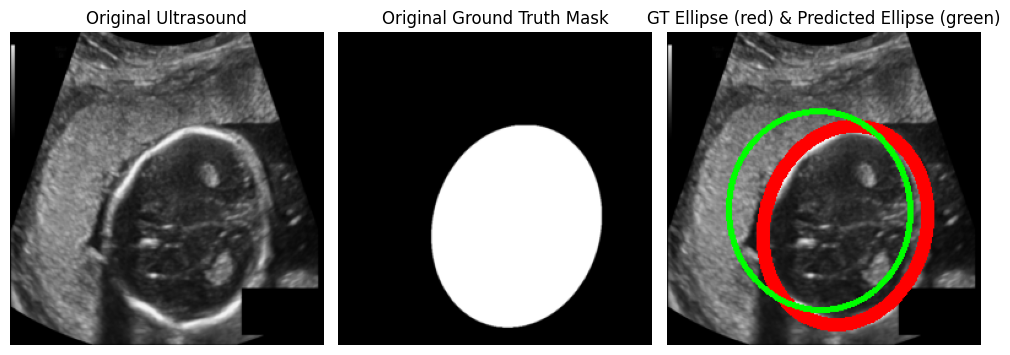

Ground Truth Parameters: 111.35035705566406 - 124.04667663574219 - 186.49282836914062 - 156.67015075683594 - 267.67912304937005
Predicted Parameters: 128.71298217773438 - 145.1041717529297 - 168.89476013183594 - 144.31224060058594 - 264.48989223797605


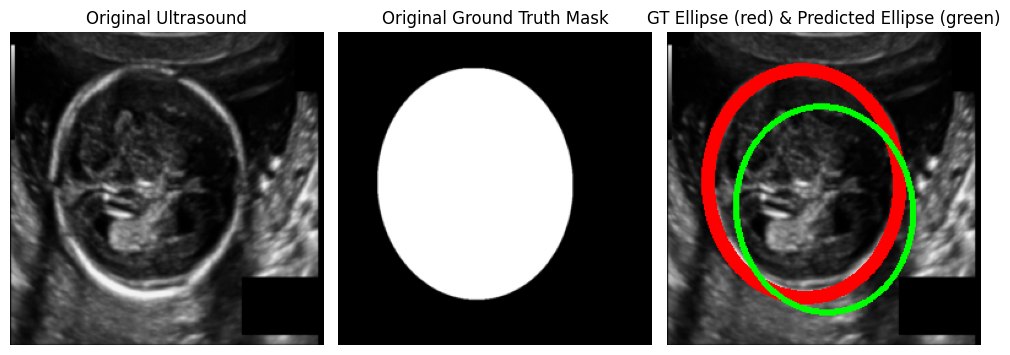

Ground Truth Parameters: 122.82154083251953 - 128.16268920898438 - 227.8090362548828 - 188.51185607910156 - 267.21510327697956
Predicted Parameters: 118.45259857177734 - 137.72837829589844 - 209.4333953857422 - 191.949951171875 - 265.14965280535966


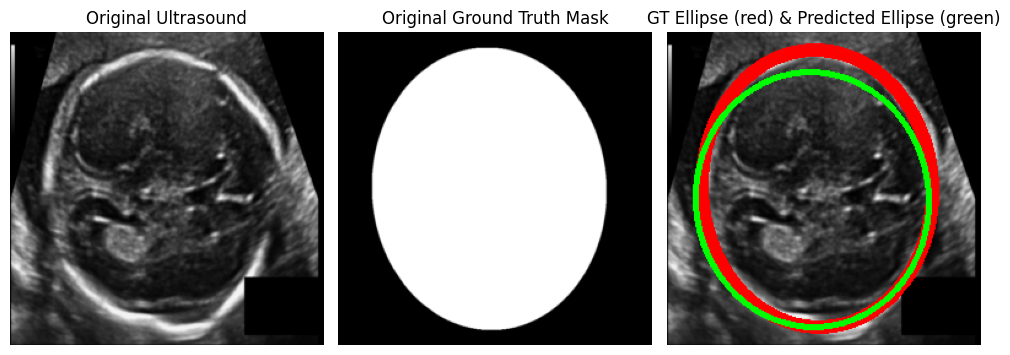

Ground Truth Parameters: 117.34725189208984 - 130.16856384277344 - 193.7854766845703 - 162.6739959716797 - 96.91378819381144
Predicted Parameters: 125.29912567138672 - 131.33828735351562 - 179.42576599121094 - 160.1107940673828 - 268.21994402899224


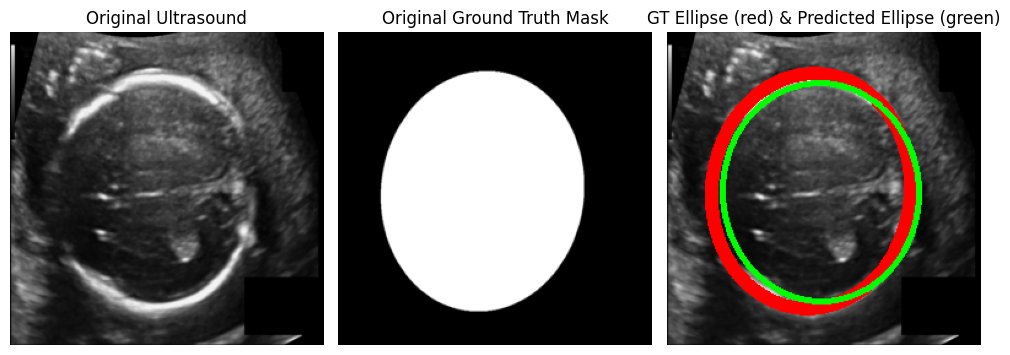

Ground Truth Parameters: 109.85115814208984 - 146.78018188476562 - 140.99200439453125 - 117.56570434570312 - 267.8585205373493
Predicted Parameters: 128.8035125732422 - 135.908935546875 - 156.48110961914062 - 140.88189697265625 - 266.95134549864406


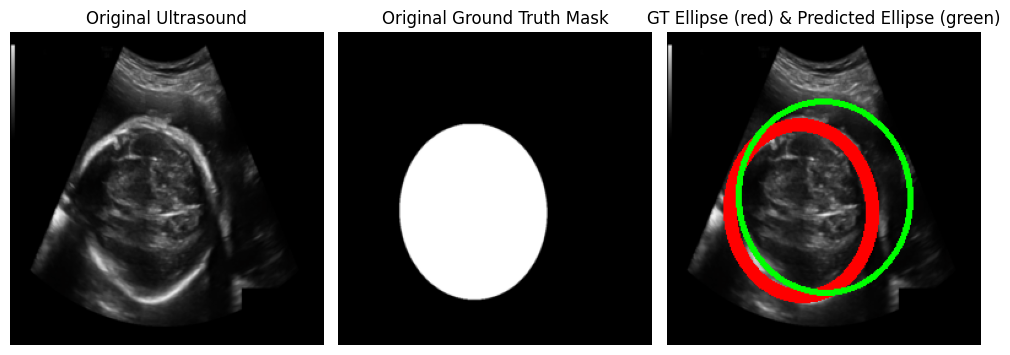

In [ ]:
plot_predictions_vs_gt(model_eval, test_loader)

# Test with an image from outside the dataset



In [ ]:
INTERNET_IMAGES_ZIP = os.path.join(DATA_DIR, "image_internet.zip")

# Load the trained model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "aggressive_ft_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training


# 2. Instanciar el dataset en modo Test (masks_zip_path=None)
internet_dataset = FetalEllipseDataset(
    images_zip_path=INTERNET_IMAGES_ZIP,
    masks_zip_path=None,        # Al ser None, se activa el modo test automáticamente
    image_transform=img_transforms
)

# 3. Crear el DataLoader
internet_loader = DataLoader(
    internet_dataset,
    batch_size=1,               # Batch size de 1 es ideal para inferencia y guardar resultados uno a uno
    shuffle=False               # No necesitas barajar para evaluar
)

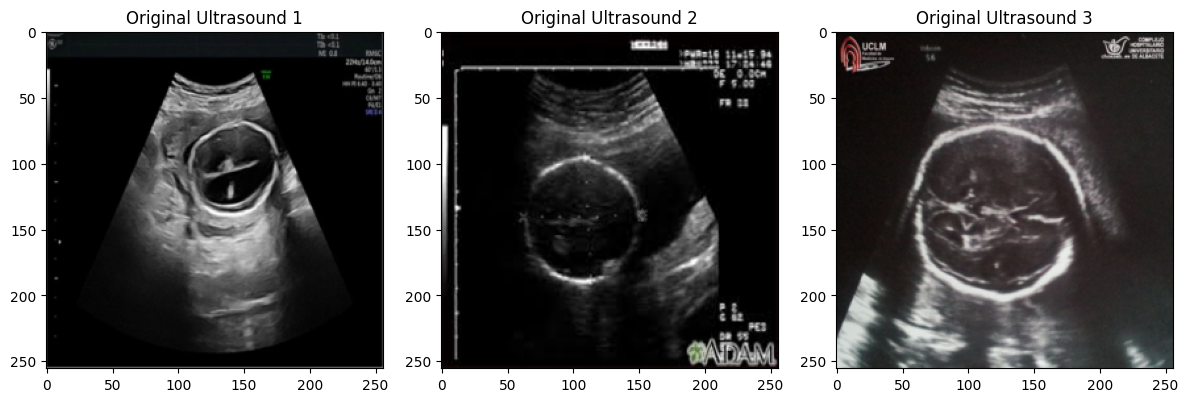

In [ ]:
plt.figure(figsize=(12, 4))

for idx, sample in enumerate(internet_loader.dataset):
  # if idx == 1: continue
  image_tensor = sample[0]
  image_np = image_tensor.permute(1, 2, 0).numpy()

  # Left: Original Ultrasound
  plt.subplot(1, 3, idx+1)
  plt.title(f"Original Ultrasound {idx+1}")
  plt.imshow(image_np)
  plt.axis('on')

plt.tight_layout()
plt.show()


In [ ]:
with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria
    predictions = []

    # Iteramos directamente sobre el dataset
    for idx, (image, _, _) in enumerate(internet_dataset):

        # 1. Añadimos la dimensión de batch artificialmente: de (3, 256, 256) a (1, 3, 256, 256)
        image_4d = image.unsqueeze(0)

        # 2. La movemos a la GPU/CPU
        image_4d = image_4d.to(device)

        # 3. Realizar la predicción
        outputs = model_eval(image_4d)

        # outputs has shape (1, 6). squeeze() to eliminate dim 1
        # array of 6 elements.
        pred_array = outputs.cpu().squeeze().numpy()
        predictions.append(pred_array)

        # Imprimimos la predicción individual de esta imagen concreta
        print(f"Image {idx} -> Predicción: {pred_array}")

Image 0 -> Predicción: [ 0.5994743   0.59873456  0.61714107  0.4375187  -0.59165263  0.96371424]
Image 1 -> Predicción: [ 0.53130865  0.55530596  0.60081065  0.39757356 -0.23103902  0.9459122 ]
Image 2 -> Predicción: [0.5665496  0.5588934  0.6613774  0.42468762 0.44431296 0.98672134]


Predicted Parameters: 153.46542358398438 - 153.2760467529297 - 157.9881134033203 - 112.0047836303711 - 254.22650364687794


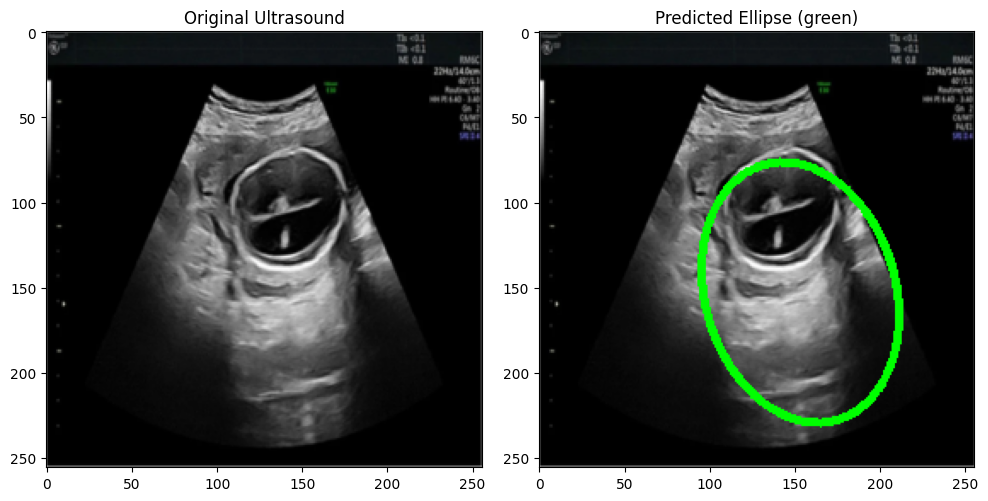

Predicted Parameters: 136.0150146484375 - 142.1583251953125 - 153.80752563476562 - 101.7788314819336 - 263.13712336923425


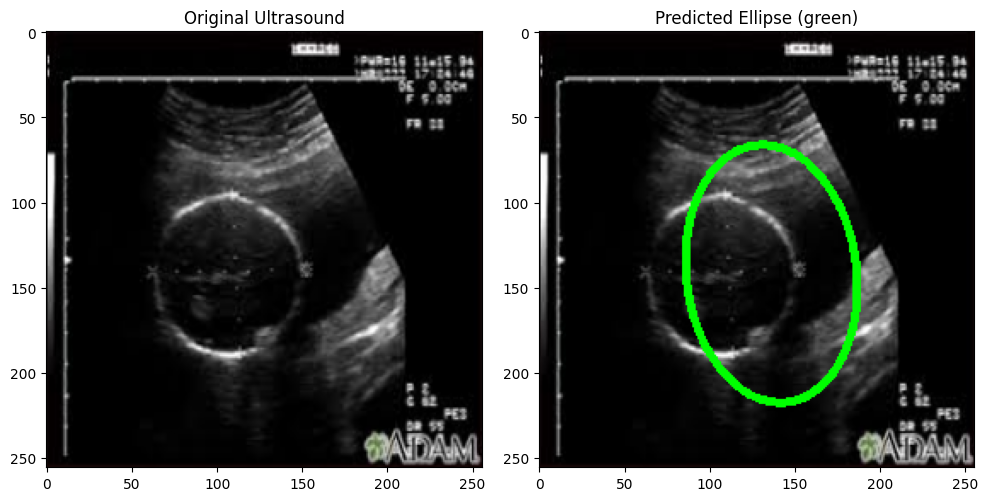

Predicted Parameters: 145.0366973876953 - 143.0767059326172 - 169.31260681152344 - 108.72003173828125 - 102.12083408213832


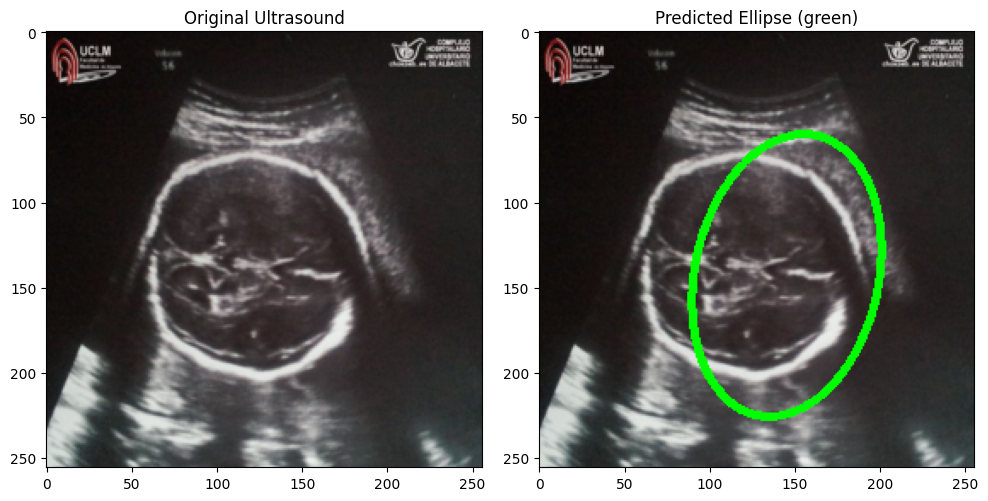

In [ ]:
for indx in range(len(internet_dataset)):

  # Load from internet dataset
  image_tensor, _, _ = internet_dataset[indx]

  # Convert to numpy FIRST so height/width are from the correct image
  image_np = image_tensor.permute(1, 2, 0).numpy()
  height, width = image_np.shape[:2]  # ← now correctly from the new image

  input_tensor = image_tensor.unsqueeze(0).to(device)

  predicted_target = predictions[indx]

  pred_xc, pred_yc, pred_dmax, pred_dmin, pred_theta = denormalize_ellipse_parameters(
      predicted_target, width, height
  )
  pred_theta += 90

  print("Predicted Parameters:", pred_xc, "-", pred_yc, "-", pred_dmax, "-", pred_dmin, "-", pred_theta)

  ellipse_image = image_np.copy()
  cv2.ellipse(
      ellipse_image,
      (int(pred_xc), int(pred_yc)),
      (int(pred_dmax / 2), int(pred_dmin / 2)),
      int(pred_theta),
      0, 360,
      (0, 255, 0),
      3
  )

  # 6. Plot side-by-side using Matplotlib
  plt.figure(figsize=(10, 5))

  # Left: Original Ultrasound
  plt.subplot(1, 2, 1)
  plt.title("Original Ultrasound")
  plt.imshow(image_np)
  plt.axis('on')

  # Right: Ellipse Fit Overlay
  plt.subplot(1, 2, 2)
  plt.title("Predicted Ellipse (green)")
  plt.imshow(ellipse_image)
  plt.axis('on')

  plt.tight_layout()
  plt.show()


# Fine Tuning: Training the last convolutional layers too

We can try:
1. moderate fine-tuning (fetures[-2:])
2. aggressive fine-tuning (fetures[-6:])

In [ ]:
# Load the trained model (only regression layer)
model = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "train_classifier_only_model.pt") # we load the weights from the training ONLY classifier
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.train() # set to training mode

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 108MB/s]


EllipseNet(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv

## Moderate Fine-Tuning

In [ ]:
# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze last convolution blocks
for param in model.backbone.features[-2:].parameters():
  param.requires_grad = True

In [ ]:
# Define the loss function
criterion = nn.SmoothL1Loss()

# Optimizer with different learning rates for the classifier and last conv. blocks
optimizer = optim.Adam([
    {
        "params": model.backbone.features[-2:].parameters(),
        "lr": 1e-5
    },
    {
        "params": model.backbone.classifier.parameters(),
        "lr": 1e-3
    }
])

model = model.to(device)

print("--- Training last 2 conv. blocks + classifier w/o data augmentation ---")

losses_list = train(model, train_loader, val_loader, criterion, optimizer, device=device, num_epochs=15, model_name="moderate_ft_model.pt", results_path=RESULTS_DIR)

--- Training last 2 conv. blocks + classifier w/o data augmentation ---
Epoch 1
Train Loss: 0.01099 | Train MAE: 0.09534 | Val Loss: 0.01533 | Val MAE: 0.09675 | Time: 0m 25.92s

Epoch 2
Train Loss: 0.01011 | Train MAE: 0.09114 | Val Loss: 0.01315 | Val MAE: 0.09256 | Time: 0m 26.09s

Epoch 3
Train Loss: 0.01046 | Train MAE: 0.09182 | Val Loss: 0.01278 | Val MAE: 0.09105 | Time: 0m 26.72s

Epoch 4
Train Loss: 0.00968 | Train MAE: 0.08939 | Val Loss: 0.01611 | Val MAE: 0.11203 | Time: 0m 27.32s

Epoch 5
Train Loss: 0.00956 | Train MAE: 0.08833 | Val Loss: 0.01528 | Val MAE: 0.09614 | Time: 0m 27.63s

Epoch 6
Train Loss: 0.00921 | Train MAE: 0.08486 | Val Loss: 0.01316 | Val MAE: 0.09378 | Time: 0m 26.44s

Epoch 7
Train Loss: 0.00979 | Train MAE: 0.09023 | Val Loss: 0.01718 | Val MAE: 0.10610 | Time: 0m 26.53s

Epoch 8
Train Loss: 0.01037 | Train MAE: 0.09159 | Val Loss: 0.01510 | Val MAE: 0.09535 | Time: 0m 26.41s

Epoch 9
Train Loss: 0.00874 | Train MAE: 0.08513 | Val Loss: 0.01378 | V

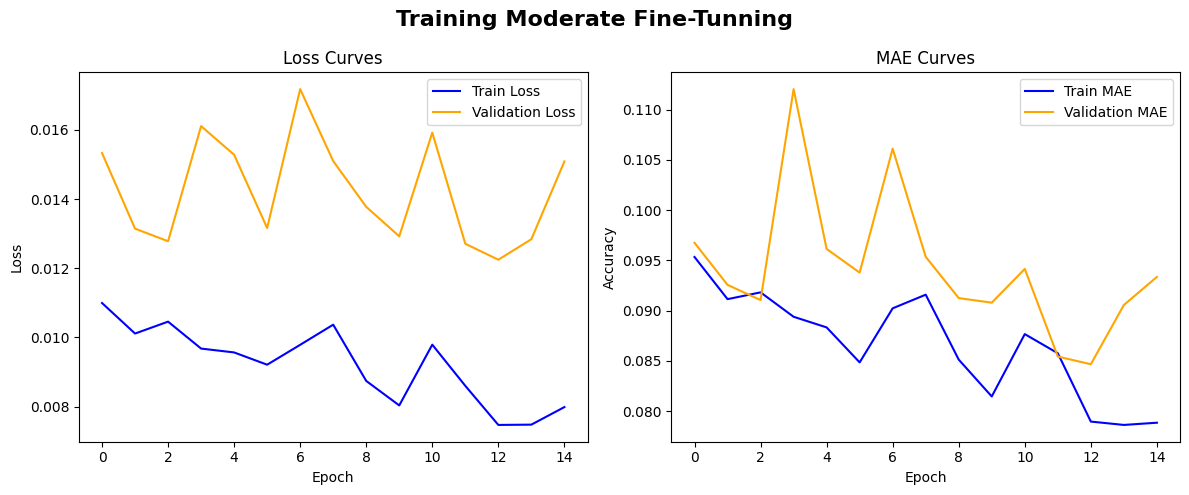

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training Moderate Fine-Tunning")

In [ ]:
# Load the trained model -> moderate_ft_model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "moderate_ft_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae = val_step(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print("--- model's performance on test set ---")
print(f"Average Loss:{avg_test_loss:.4f}")
print(f"Average MAE:{avg_test_mae:.2f}")


--- model's performance on test set ---
Average Loss:0.0126
Average MAE:0.09


Ground Truth Parameters: 126.34540557861328 - 117.10679626464844 - 178.82061767578125 - 164.27203369140625 - 265.62631230592007
Predicted Parameters: 123.22740936279297 - 126.89495086669922 - 196.53375244140625 - 166.9937744140625 - 263.1569774570863


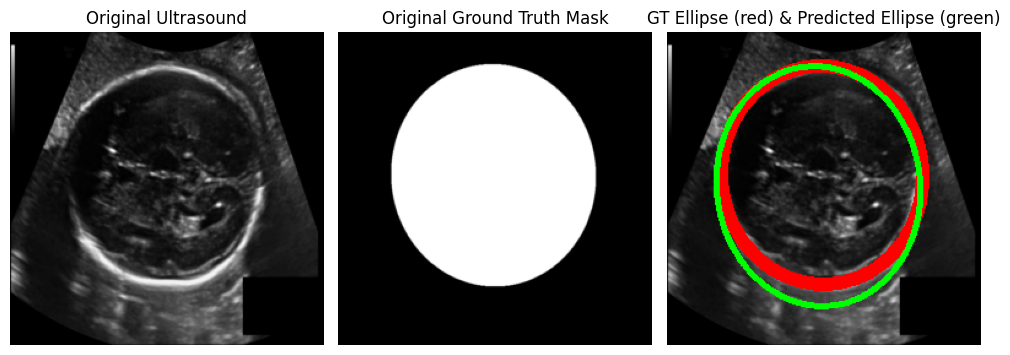

Ground Truth Parameters: 144.30410766601562 - 128.5962371826172 - 104.75619506835938 - 79.37323760986328 - 96.17791991394665
Predicted Parameters: 126.47614288330078 - 121.1740951538086 - 126.86585235595703 - 98.10093688964844 - 267.55679807508193


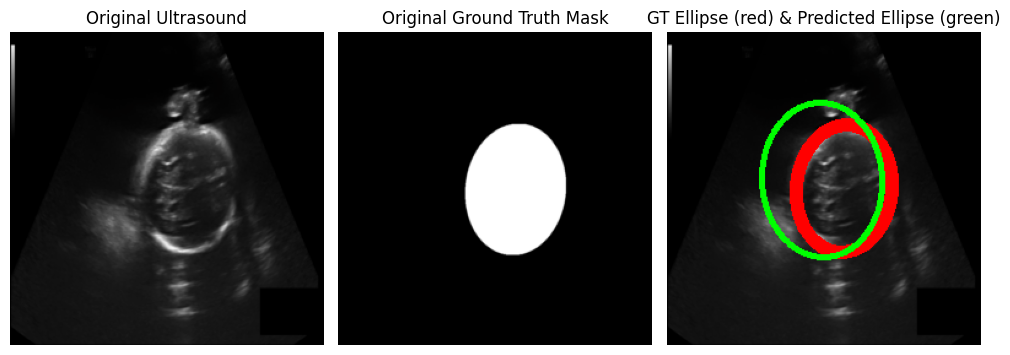

Ground Truth Parameters: 130.2976837158203 - 155.08309936523438 - 153.2643280029297 - 113.7633056640625 - 101.6954017560223
Predicted Parameters: 135.85240173339844 - 143.58157348632812 - 164.83261108398438 - 122.15525817871094 - 92.66184690784684


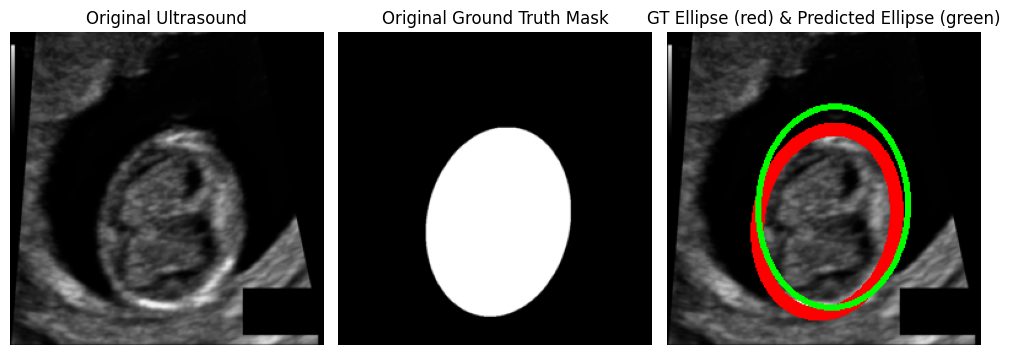

Ground Truth Parameters: 128.20693969726562 - 129.67503356933594 - 161.03567504882812 - 140.69439697265625 - 268.3206635151505
Predicted Parameters: 130.19346618652344 - 124.2987060546875 - 168.3109130859375 - 151.68743896484375 - 263.7494513195986


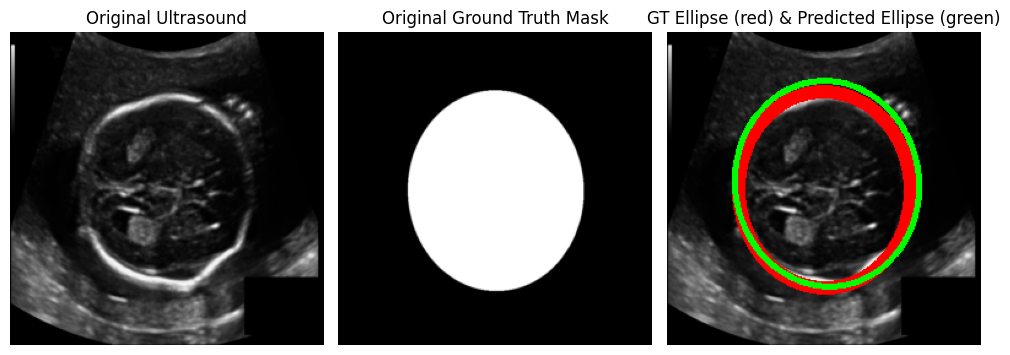

Ground Truth Parameters: 124.89350128173828 - 117.23819732666016 - 140.3055419921875 - 113.66670227050781 - 269.64042663231294
Predicted Parameters: 127.12214660644531 - 125.48853302001953 - 154.55535888671875 - 131.9006805419922 - 91.09547127166779


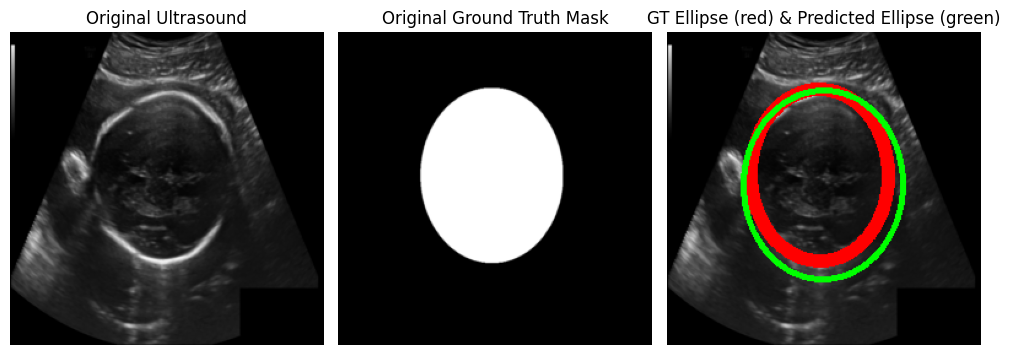

In [ ]:
plot_predictions_vs_gt(model_eval, test_loader)

## Aggressive Fine-Tuning

In [ ]:
# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze last convolution blocks
for param in model.backbone.features[-6:].parameters():
  param.requires_grad = True

In [ ]:
# Define the loss function
criterion = nn.SmoothL1Loss()

# Optimizer with different learning rates for the classifier and last conv. blocks
optimizer = optim.Adam([
    {
        "params": model.backbone.features[-6:].parameters(),
        "lr": 1e-5
    },
    {
        "params": model.backbone.classifier.parameters(),
        "lr": 1e-3
    }
])

model = model.to(device)

print("--- Training Aggressive Fine-Tunning w/o Data Augmentation ---")

losses_list = train(model, train_loader, val_loader, criterion, optimizer, device=device, num_epochs=15, model_name="aggressive_ft_model.pt", results_path=RESULTS_DIR)

--- Training Aggressive Fine-Tunning w/o Data Augmentation ---
Epoch 1
Train Loss: 0.01148 | Train MAE: 0.09591 | Val Loss: 0.01359 | Val MAE: 0.09266 | Time: 0m 26.79s

Epoch 2
Train Loss: 0.00969 | Train MAE: 0.08931 | Val Loss: 0.01661 | Val MAE: 0.09884 | Time: 0m 27.37s

Epoch 3
Train Loss: 0.00929 | Train MAE: 0.08770 | Val Loss: 0.01445 | Val MAE: 0.09585 | Time: 0m 27.95s

Epoch 4
Train Loss: 0.00979 | Train MAE: 0.08861 | Val Loss: 0.01428 | Val MAE: 0.10054 | Time: 0m 27.38s

Epoch 5
Train Loss: 0.00936 | Train MAE: 0.08737 | Val Loss: 0.02165 | Val MAE: 0.12191 | Time: 0m 26.80s

Epoch 6
Train Loss: 0.00940 | Train MAE: 0.08707 | Val Loss: 0.01396 | Val MAE: 0.08924 | Time: 0m 26.48s

Epoch 7
Train Loss: 0.00805 | Train MAE: 0.08137 | Val Loss: 0.01371 | Val MAE: 0.10144 | Time: 0m 27.14s

Epoch 8
Train Loss: 0.00774 | Train MAE: 0.08132 | Val Loss: 0.01356 | Val MAE: 0.09346 | Time: 0m 27.61s

Epoch 9
Train Loss: 0.00732 | Train MAE: 0.07964 | Val Loss: 0.01254 | Val MAE: 0

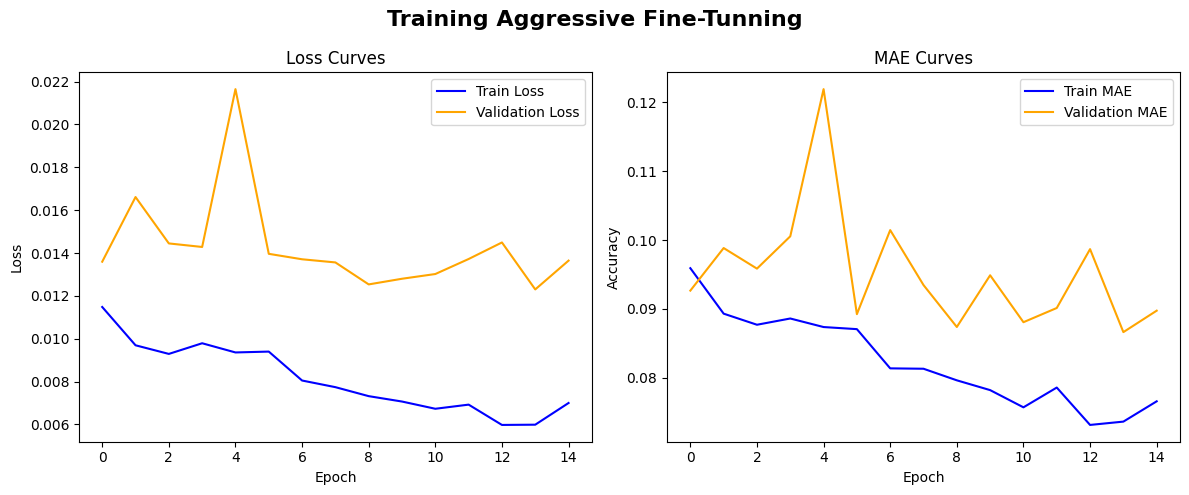

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training Aggressive Fine-Tunning")

In [ ]:
# Load the trained model -> aggressive_ft_model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "aggressive_ft_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae = val_step(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print("--- model's performance on test set ---")
print(f"Average Loss:{avg_test_loss:.4f}")
print(f"Average MAE:{avg_test_mae:.2f}")


--- model's performance on test set ---
Average Loss:0.0127
Average MAE:0.09


Ground Truth Parameters: 143.62510681152344 - 137.96434020996094 - 178.372802734375 - 155.43301391601562 - 90.26563802373151
Predicted Parameters: 116.44580078125 - 135.64657592773438 - 158.92214965820312 - 136.2068328857422 - 268.5300940620568


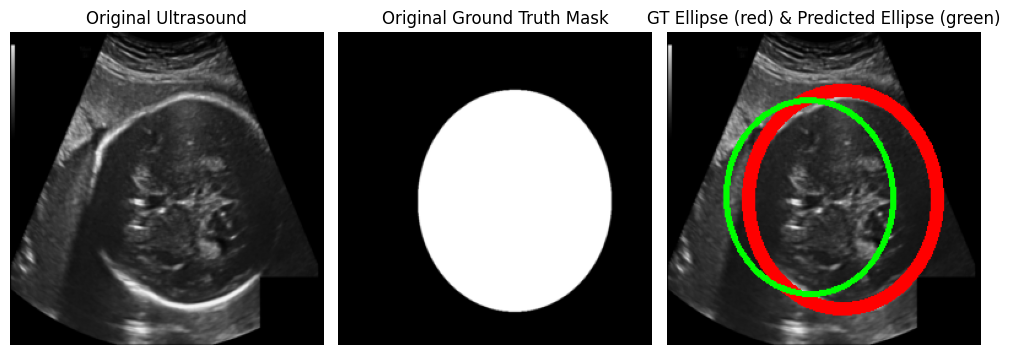

Ground Truth Parameters: 125.08033752441406 - 121.21913146972656 - 141.8817901611328 - 99.81271362304688 - 100.89044693082047
Predicted Parameters: 131.17454528808594 - 132.6364288330078 - 141.30807495117188 - 94.71360778808594 - 100.7668477829654


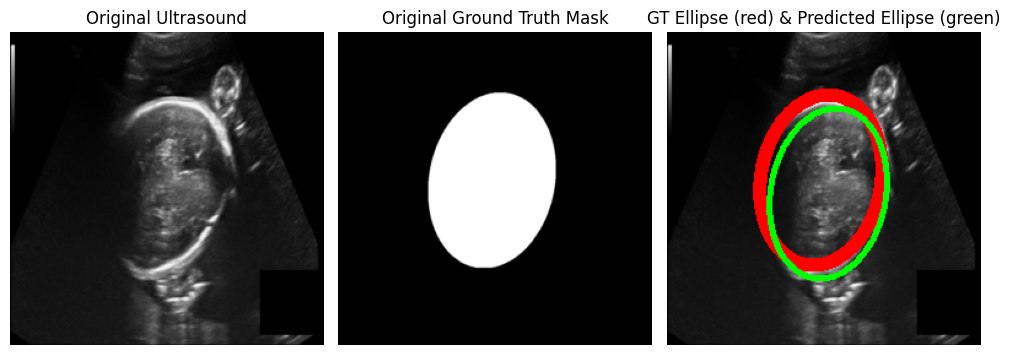

Ground Truth Parameters: 133.23614501953125 - 109.26799011230469 - 163.7488555908203 - 131.4623565673828 - 268.95758052601434
Predicted Parameters: 125.330078125 - 107.92437744140625 - 145.6543731689453 - 126.48690795898438 - 265.82329395826434


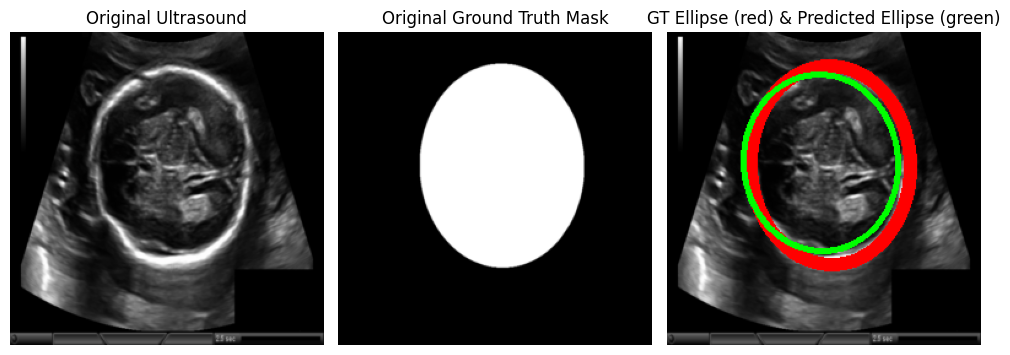

Ground Truth Parameters: 113.43052673339844 - 125.58208465576172 - 162.72088623046875 - 134.12413024902344 - 252.5127867401537
Predicted Parameters: 121.28256225585938 - 123.37620544433594 - 161.1028289794922 - 138.84652709960938 - 93.40453786636347


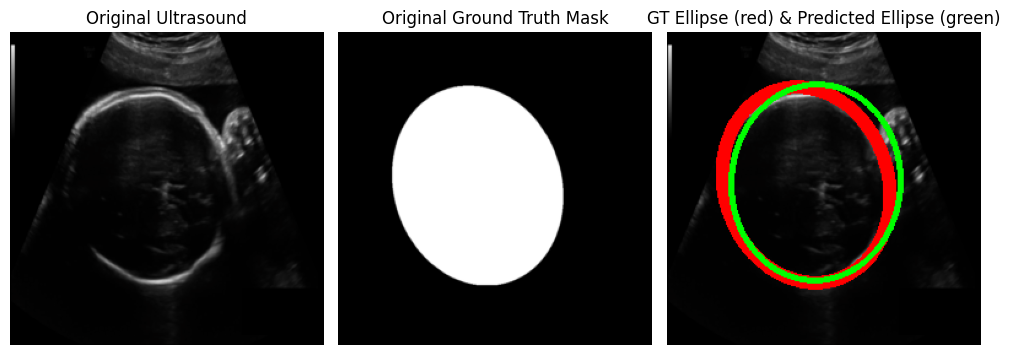

Ground Truth Parameters: 146.57672119140625 - 128.6309814453125 - 194.7715301513672 - 171.18807983398438 - 267.1184996858417
Predicted Parameters: 133.01512145996094 - 134.81944274902344 - 188.0364990234375 - 155.69326782226562 - 269.33652422133287


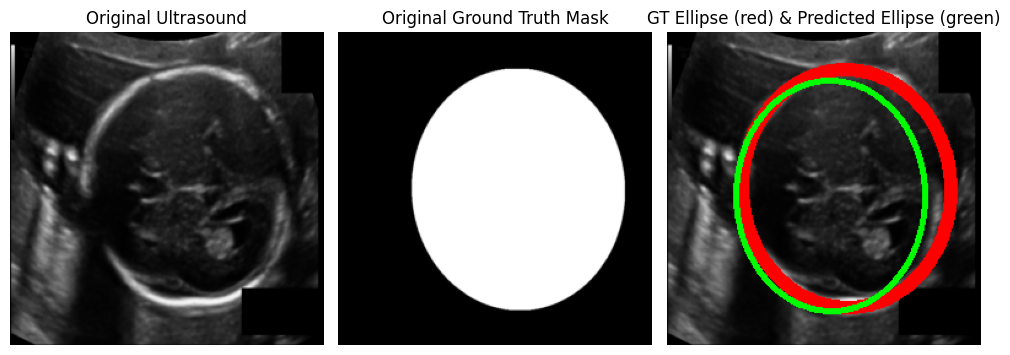

In [ ]:
plot_predictions_vs_gt(model_eval, test_loader)

## Aggressive Fine-Tuning w/ Data Augmentation

In [ ]:
# FIRST EXECUTE THE NECESSARY CELLS FROM PREVIOUS SECTIONS

# Define the loss function
criterion = nn.SmoothL1Loss()

# Optimizer with different learning rates for the classifier and last conv. blocks
optimizer = optim.Adam([
    {
        "params": model.backbone.features[-4:].parameters(),
        "lr": 1e-5
    },
    {
        "params": model.backbone.classifier.parameters(),
        "lr": 1e-3
    }
])

model = model.to(device)

print("--- Training Aggressive Fine-Tunning w/ Data Augmentation ---")

losses_list = train(model, train_loader_da, val_loader, criterion, optimizer, device=device, num_epochs=15, model_name="aggressive_ft_da_model.pt", results_path=RESULTS_DIR)

--- Training Aggressive Fine-Tunning w/ Data Augmentation ---
Epoch 1
Train Loss: 0.02455 | Train MAE: 0.13475 | Val Loss: 0.01641 | Val MAE: 0.10477 | Time: 1m 41.76s

Epoch 2
Train Loss: 0.02205 | Train MAE: 0.12998 | Val Loss: 0.01721 | Val MAE: 0.10733 | Time: 0m 27.36s

Epoch 3
Train Loss: 0.02140 | Train MAE: 0.12343 | Val Loss: 0.01256 | Val MAE: 0.08765 | Time: 0m 26.33s

Epoch 4
Train Loss: 0.02086 | Train MAE: 0.12144 | Val Loss: 0.01244 | Val MAE: 0.09143 | Time: 0m 27.11s

Epoch 5
Train Loss: 0.01857 | Train MAE: 0.11899 | Val Loss: 0.01329 | Val MAE: 0.09147 | Time: 0m 26.96s

Epoch 6
Train Loss: 0.01641 | Train MAE: 0.11279 | Val Loss: 0.02062 | Val MAE: 0.11165 | Time: 0m 27.60s

Epoch 7
Train Loss: 0.01724 | Train MAE: 0.11290 | Val Loss: 0.01253 | Val MAE: 0.09075 | Time: 0m 27.60s

Epoch 8
Train Loss: 0.01566 | Train MAE: 0.10829 | Val Loss: 0.01266 | Val MAE: 0.08830 | Time: 0m 27.36s

Epoch 9
Train Loss: 0.01448 | Train MAE: 0.10281 | Val Loss: 0.01711 | Val MAE: 0.

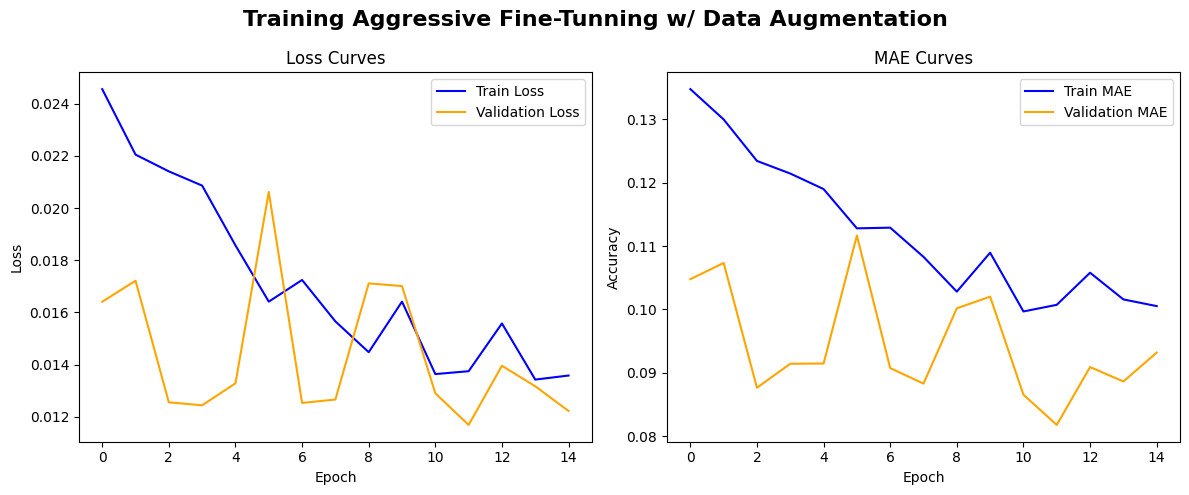

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training Aggressive Fine-Tunning w/ Data Augmentation")

In [ ]:
# Load the trained model -> aggressive_ft_model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "aggressive_ft_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae = val_step(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print("--- model's performance on test set ---")
print(f"Average Loss:{avg_test_loss:.4f}")
print(f"Average MAE:{avg_test_mae:.2f}")


--- model's performance on test set ---
Average Loss:0.0130
Average MAE:0.09


Ground Truth Parameters: 107.97664642333984 - 110.05777740478516 - 183.15489196777344 - 145.37998962402344 - 97.08605584029087
Predicted Parameters: 128.43507385253906 - 123.47172546386719 - 173.96182250976562 - 137.16310119628906 - 268.662110262076


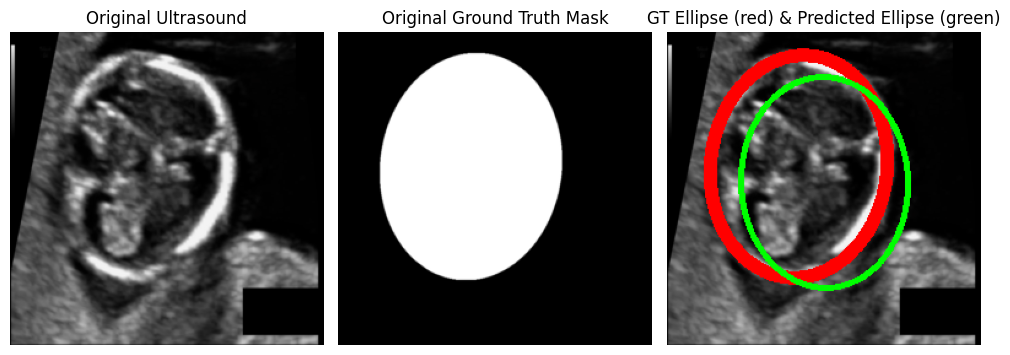

Ground Truth Parameters: 118.62557220458984 - 147.98207092285156 - 156.16932678222656 - 119.70011901855469 - 90.62605230229636
Predicted Parameters: 127.20578002929688 - 125.91987609863281 - 159.1788330078125 - 128.44580078125 - 100.24142439343821


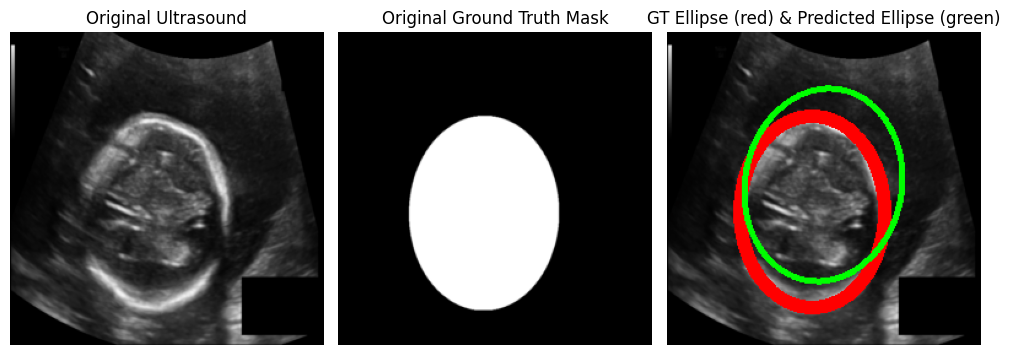

Ground Truth Parameters: 138.6755828857422 - 126.70860290527344 - 222.21603393554688 - 180.65518188476562 - 263.43360890700353
Predicted Parameters: 117.81938934326172 - 128.11093139648438 - 200.43292236328125 - 171.19857788085938 - 90.89546709972224


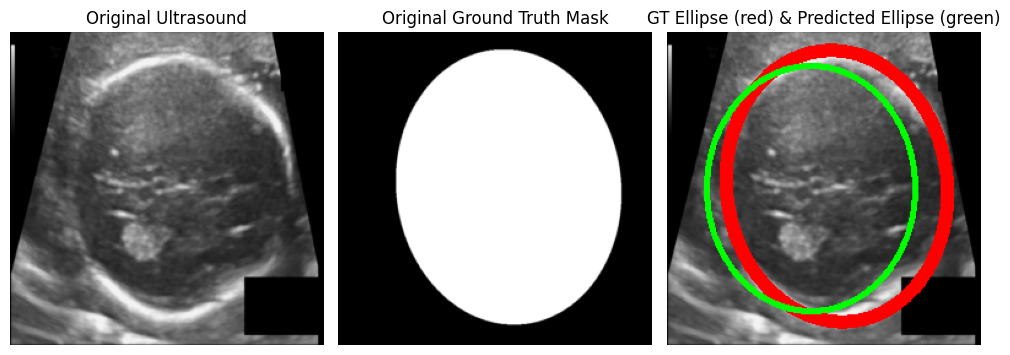

Ground Truth Parameters: 118.40660858154297 - 136.6347198486328 - 194.90684509277344 - 163.44973754882812 - 97.72398763804622
Predicted Parameters: 129.66964721679688 - 144.1793212890625 - 193.83251953125 - 160.61972045898438 - 97.5962412973203


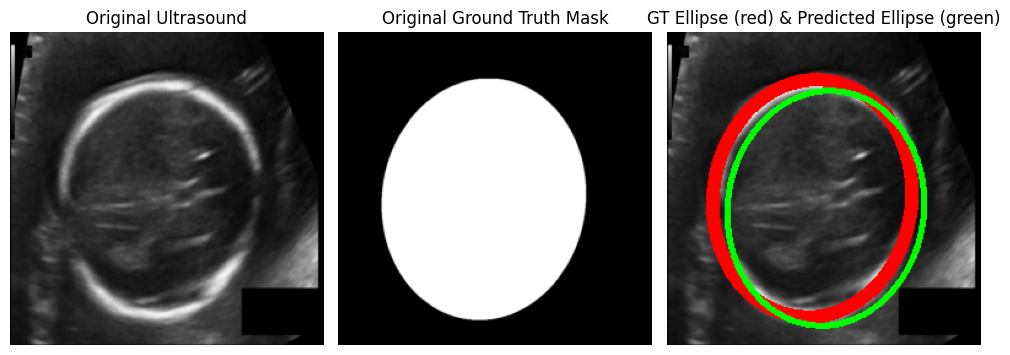

Ground Truth Parameters: 129.08786010742188 - 107.28131103515625 - 148.9872589111328 - 122.12080383300781 - 267.0215149026975
Predicted Parameters: 118.5816879272461 - 131.45126342773438 - 169.92684936523438 - 135.28602600097656 - 269.7275579740502


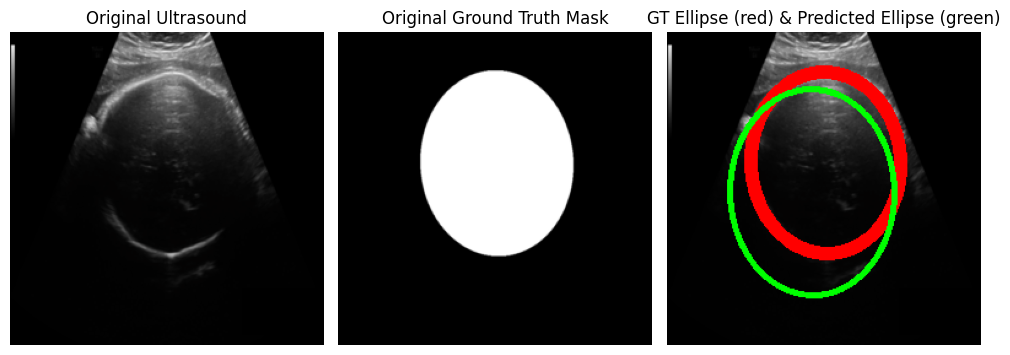

In [ ]:
plot_predictions_vs_gt(model_eval, test_loader)

# MobileNetv3_Large

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

class EllipseNet_large(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = models.mobilenet_v3_large(
            weights="DEFAULT"
        )

        in_features = self.backbone.classifier[-1].in_features

        # substitute the classifier
        self.backbone.classifier = nn.Sequential(
            nn.Linear(960, 128), # from 576 to 960
            nn.Hardswish(),
            nn.Dropout(0.2),

            # output:
            # cx, cy, a, b, theta (decomposed in sin(2theta) and cos(2theta))
            nn.Linear(128, 6)
        )

    def forward(self, x):
        return self.backbone(x)


In [ ]:
model = EllipseNet_large()

In [ ]:
# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier only
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze some later blocks
for param in model.backbone.features[-6:].parameters():
  param.requires_grad = True

In [ ]:
# Define the loss function
criterion = nn.SmoothL1Loss()

# Pass different learning rates to the optimizer
optimizer = optim.Adam([
    {'params': model.backbone.features.parameters(), 'lr': 1e-5}, # Tiny LR for backbone
    {'params': model.backbone.classifier.parameters(), 'lr': 1e-3} # Normal LR for head
])

model = model.to(device)

print("--- Training MobileNetv3_Large Last Conv. Blocks and Classifier w/ Data Augmentation ---")

losses_list = train(model, train_loader_da, val_loader, criterion, optimizer, device=device, num_epochs=15, model_name="large_da_model.pt", results_path=RESULTS_DIR)


--- Training MobileNetv3_Large Last Conv. Blocks and Classifier w/ Data Augmentation ---
Epoch 1
Train Loss: 0.03954 | Train MAE: 0.19822 | Val Loss: 0.04222 | Val MAE: 0.25575 | Time: 0m 29.51s

Epoch 2
Train Loss: 0.02749 | Train MAE: 0.15174 | Val Loss: 0.03079 | Val MAE: 0.20704 | Time: 0m 29.41s

Epoch 3
Train Loss: 0.02687 | Train MAE: 0.14775 | Val Loss: 0.02474 | Val MAE: 0.17179 | Time: 0m 29.43s

Epoch 4
Train Loss: 0.02428 | Train MAE: 0.13889 | Val Loss: 0.02148 | Val MAE: 0.14839 | Time: 0m 30.20s

Epoch 5
Train Loss: 0.02409 | Train MAE: 0.13700 | Val Loss: 0.02780 | Val MAE: 0.16419 | Time: 0m 29.61s

Epoch 6
Train Loss: 0.02397 | Train MAE: 0.13701 | Val Loss: 0.01844 | Val MAE: 0.12528 | Time: 0m 28.89s

Epoch 7
Train Loss: 0.02227 | Train MAE: 0.13059 | Val Loss: 0.01693 | Val MAE: 0.12441 | Time: 0m 29.24s

Epoch 8
Train Loss: 0.02303 | Train MAE: 0.13193 | Val Loss: 0.02214 | Val MAE: 0.13120 | Time: 0m 29.58s

Epoch 9
Train Loss: 0.02236 | Train MAE: 0.12830 | Val 

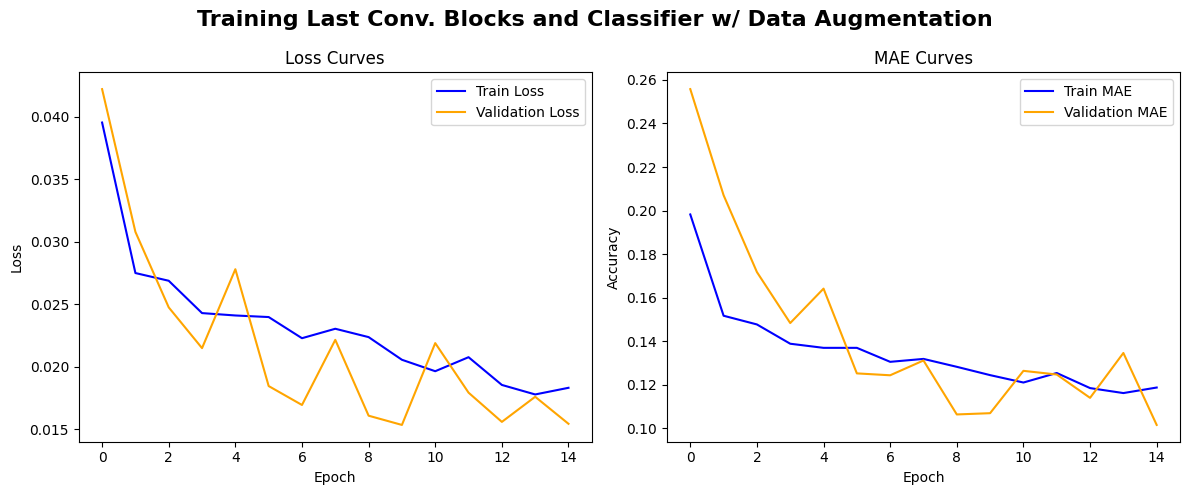

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training Last Conv. Blocks and Classifier w/ Data Augmentation")

In [ ]:
# Load the trained model -> large_da_model
model_eval = EllipseNet_large()
model_path = os.path.join(RESULTS_DIR, "large_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae = val_step(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print("--- model's performance on test set ---")
print(f"Average Loss:{avg_test_loss:.4f}")
print(f"Average MAE:{avg_test_mae:.2f}")


--- model's performance on test set ---
Average Loss:0.0155
Average MAE:0.11


Ground Truth Parameters: 111.6120834350586 - 121.52249145507812 - 146.4666290283203 - 83.7688217163086 - 91.83638039476233
Predicted Parameters: 109.57036590576172 - 102.94908905029297 - 137.0601043701172 - 103.64083099365234 - 264.33200736880167


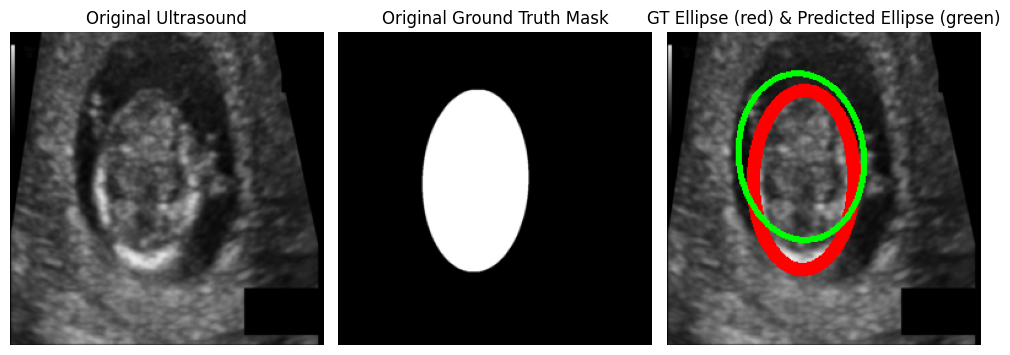

Ground Truth Parameters: 131.38180541992188 - 117.10465240478516 - 171.0964813232422 - 154.78921508789062 - 251.5407404824862
Predicted Parameters: 115.28047943115234 - 118.35308074951172 - 186.1385498046875 - 159.05978393554688 - 264.8873188375549


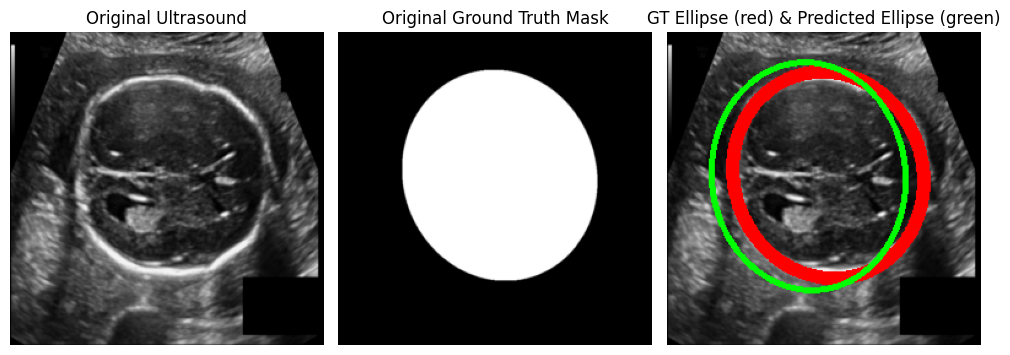

Ground Truth Parameters: 123.35953521728516 - 139.2852020263672 - 177.59153747558594 - 155.70745849609375 - 91.64242245242721
Predicted Parameters: 119.03301239013672 - 124.47066497802734 - 191.96865844726562 - 164.4016571044922 - 259.7812231713947


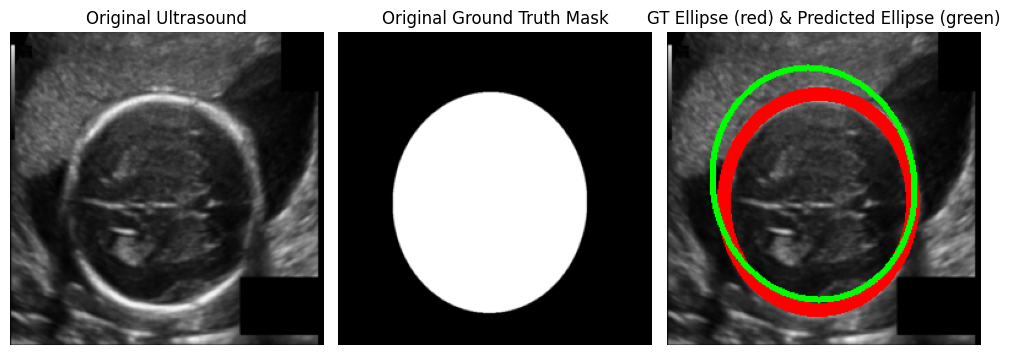

Ground Truth Parameters: 125.99101257324219 - 141.6015625 - 193.2818145751953 - 158.5470428466797 - 93.22149824194908
Predicted Parameters: 132.83377075195312 - 128.8961639404297 - 147.2675323486328 - 136.4711456298828 - 91.27692310616354


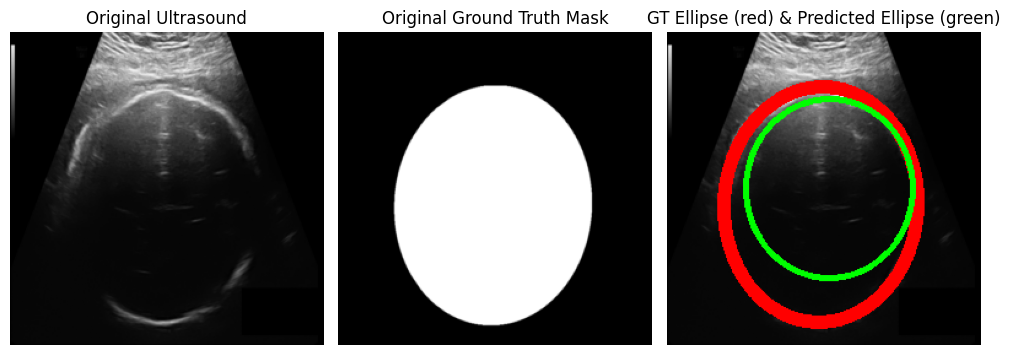

Ground Truth Parameters: 111.65717315673828 - 123.40420532226562 - 170.50994873046875 - 142.2039337158203 - 97.96428629613429
Predicted Parameters: 121.91556549072266 - 113.97958374023438 - 162.26815795898438 - 149.30320739746094 - 266.8444418947764


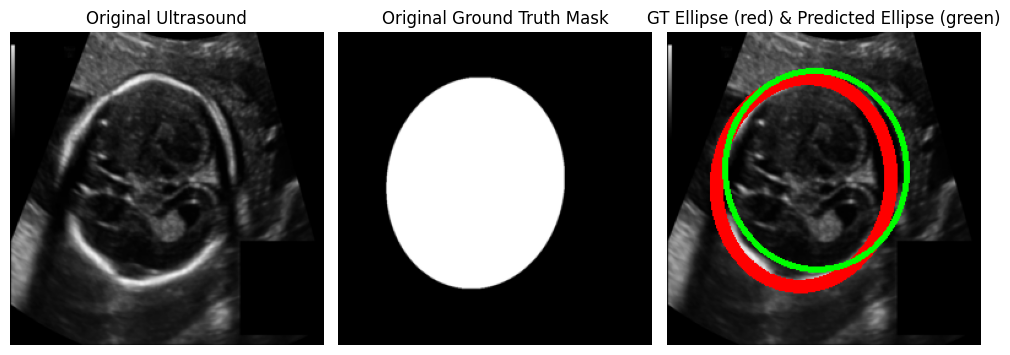

In [ ]:
plot_predictions_vs_gt(model_eval, test_loader)

In [ ]:
# print(model) # 16 blocks + classifier

EllipseNet_large(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormAct

# Running More Epochs

## EllipseNet (small) with moderate fine-tunning 50 epochs

In [ ]:
model = EllipseNet()
model.train() # set to training mode

# freeze everything
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier only
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze some later conv. blocks
for param in model.backbone.features[-2:].parameters():
  param.requires_grad = True

In [ ]:
# Define the loss function
criterion = nn.SmoothL1Loss()

# Pass different learning rates to the optimizer
optimizer = optim.Adam([
    {'params': model.backbone.features.parameters(), 'lr': 1e-5}, # Tiny LR for backbone
    {'params': model.backbone.classifier.parameters(), 'lr': 1e-3} # Normal LR for head
])

model = model.to(device)

print("--- Training MobileNetv3_Small Last Conv. Blocks and Classifier w/ Data Augmentation ---")

losses_list = train(model, train_loader_da, val_loader, criterion, optimizer, device=device, num_epochs=50, model_name="small_50epochs_da_model.pt", results_path=RESULTS_DIR)


--- Training MobileNetv3_Small Last Conv. Blocks and Classifier w/ Data Augmentation ---
Epoch 1
Train Loss: 0.03917 | Train MAE: 0.20303 | Val Loss: 0.02051 | Val MAE: 0.15271 | Time: 0m 37.94s

Epoch 2
Train Loss: 0.02169 | Train MAE: 0.14062 | Val Loss: 0.02027 | Val MAE: 0.12755 | Time: 0m 34.04s

Epoch 3
Train Loss: 0.02067 | Train MAE: 0.13521 | Val Loss: 0.02224 | Val MAE: 0.14262 | Time: 0m 35.80s

Epoch 4
Train Loss: 0.02047 | Train MAE: 0.13210 | Val Loss: 0.02132 | Val MAE: 0.13552 | Time: 0m 46.73s

Epoch 5
Train Loss: 0.02097 | Train MAE: 0.13217 | Val Loss: 0.02751 | Val MAE: 0.15777 | Time: 0m 34.88s

Epoch 6
Train Loss: 0.01959 | Train MAE: 0.12929 | Val Loss: 0.02129 | Val MAE: 0.14052 | Time: 0m 34.55s

Epoch 7
Train Loss: 0.02026 | Train MAE: 0.13020 | Val Loss: 0.01907 | Val MAE: 0.13212 | Time: 0m 34.43s

Epoch 8
Train Loss: 0.01857 | Train MAE: 0.12153 | Val Loss: 0.01754 | Val MAE: 0.11205 | Time: 0m 35.62s

Epoch 9
Train Loss: 0.01877 | Train MAE: 0.12174 | Val 

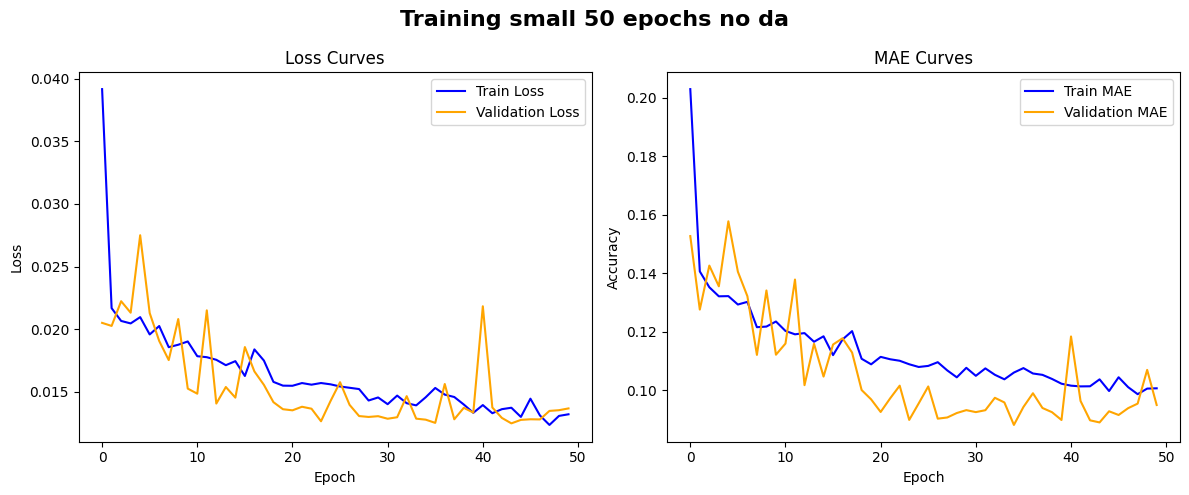

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "Training small 50 epochs no da")

Ground Truth Parameters: 123.17083740234375 - 131.54983520507812 - 204.0947723388672 - 171.88917541503906 - 93.01865326416711
Predicted Parameters: 126.07624816894531 - 119.23716735839844 - 182.87518310546875 - 143.03274536132812 - 268.24476090350913


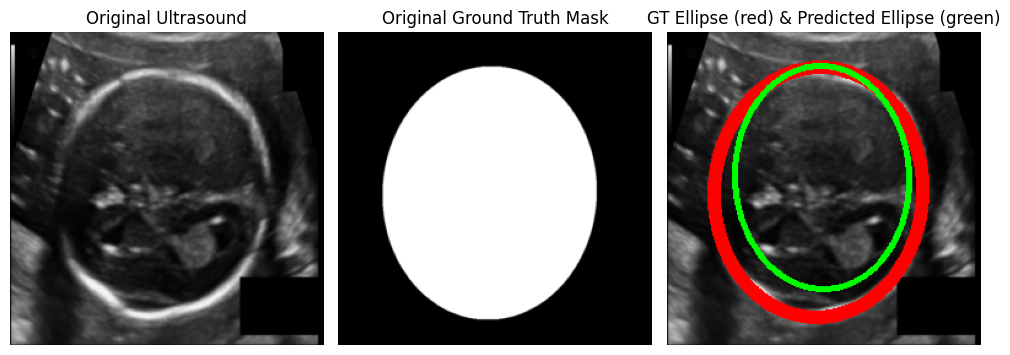

Ground Truth Parameters: 155.09405517578125 - 165.9558563232422 - 87.93302154541016 - 53.599788665771484 - 263.6329346214784
Predicted Parameters: 111.25530242919922 - 124.67830657958984 - 164.05865478515625 - 130.42364501953125 - 93.37388005094526


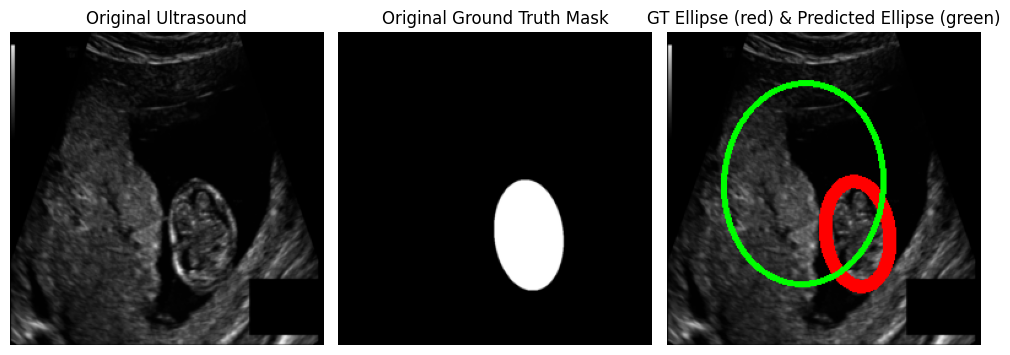

Ground Truth Parameters: 126.34540557861328 - 117.10679626464844 - 178.82061767578125 - 164.27203369140625 - 265.62631230592007
Predicted Parameters: 120.84365844726562 - 139.85975646972656 - 174.0356903076172 - 146.6398162841797 - 90.41220062842856


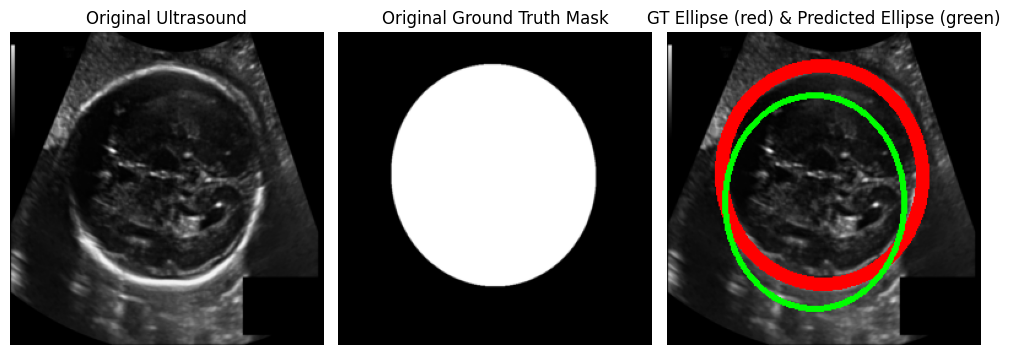

Ground Truth Parameters: 118.40660858154297 - 136.6347198486328 - 194.90684509277344 - 163.44973754882812 - 97.72398763804622
Predicted Parameters: 115.7450942993164 - 126.05818939208984 - 172.90907287597656 - 141.8968963623047 - 269.178289641016


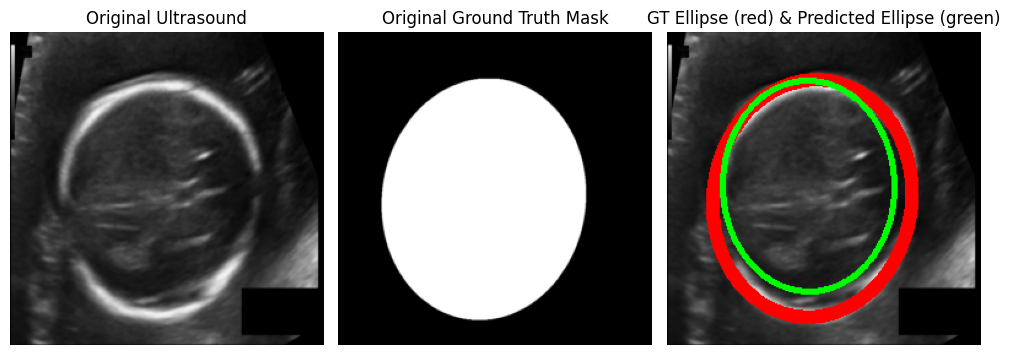

Ground Truth Parameters: 122.48360443115234 - 128.62213134765625 - 182.18568420410156 - 146.86221313476562 - 115.28821980779995
Predicted Parameters: 120.4732437133789 - 134.2762908935547 - 174.96014404296875 - 142.7027587890625 - 91.01243746706224


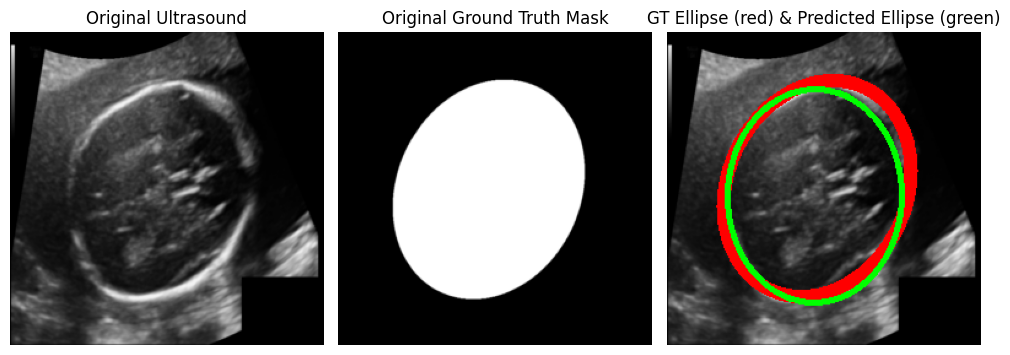

In [ ]:
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "small_50epochs_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)

plot_predictions_vs_gt(model_eval, test_loader)

## EllipseNet_large moderate fine-tunning 50 epochs

In [ ]:
model = EllipseNet_large()

# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier only
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze some later blocks
for param in model.backbone.features[-6:].parameters():
  param.requires_grad = True

# Define the loss function
criterion = nn.SmoothL1Loss()

# Pass different learning rates to the optimizer
optimizer = optim.Adam([
    {'params': model.backbone.features.parameters(), 'lr': 1e-5}, # Tiny LR for backbone
    {'params': model.backbone.classifier.parameters(), 'lr': 1e-3} # Normal LR for head
])

model = model.to(device)

print("--- Training MobileNetv3_Large Last Conv. Blocks and Classifier w/ Data Augmentation ---")

losses_list = train(model, train_loader_da, val_loader, criterion, optimizer, device=device, num_epochs=50, model_name="large_50epochs_da_model.pt", results_path=RESULTS_DIR)


--- Training MobileNetv3_Large Last Conv. Blocks and Classifier w/ Data Augmentation ---
Epoch 1
Train Loss: 0.03823 | Train MAE: 0.19974 | Val Loss: 0.05054 | Val MAE: 0.27933 | Time: 0m 38.83s

Epoch 2
Train Loss: 0.02177 | Train MAE: 0.14066 | Val Loss: 0.03675 | Val MAE: 0.22883 | Time: 0m 36.70s

Epoch 3
Train Loss: 0.01981 | Train MAE: 0.13290 | Val Loss: 0.02947 | Val MAE: 0.19691 | Time: 0m 38.27s

Epoch 4
Train Loss: 0.01887 | Train MAE: 0.12940 | Val Loss: 0.02789 | Val MAE: 0.18056 | Time: 0m 38.32s

Epoch 5
Train Loss: 0.01727 | Train MAE: 0.12269 | Val Loss: 0.01832 | Val MAE: 0.13708 | Time: 0m 36.98s

Epoch 6
Train Loss: 0.01649 | Train MAE: 0.11967 | Val Loss: 0.01701 | Val MAE: 0.12714 | Time: 0m 37.61s

Epoch 7
Train Loss: 0.01753 | Train MAE: 0.12299 | Val Loss: 0.01974 | Val MAE: 0.13326 | Time: 0m 37.00s

Epoch 8
Train Loss: 0.01651 | Train MAE: 0.11844 | Val Loss: 0.01627 | Val MAE: 0.11814 | Time: 0m 36.89s

Epoch 9
Train Loss: 0.01565 | Train MAE: 0.11493 | Val 

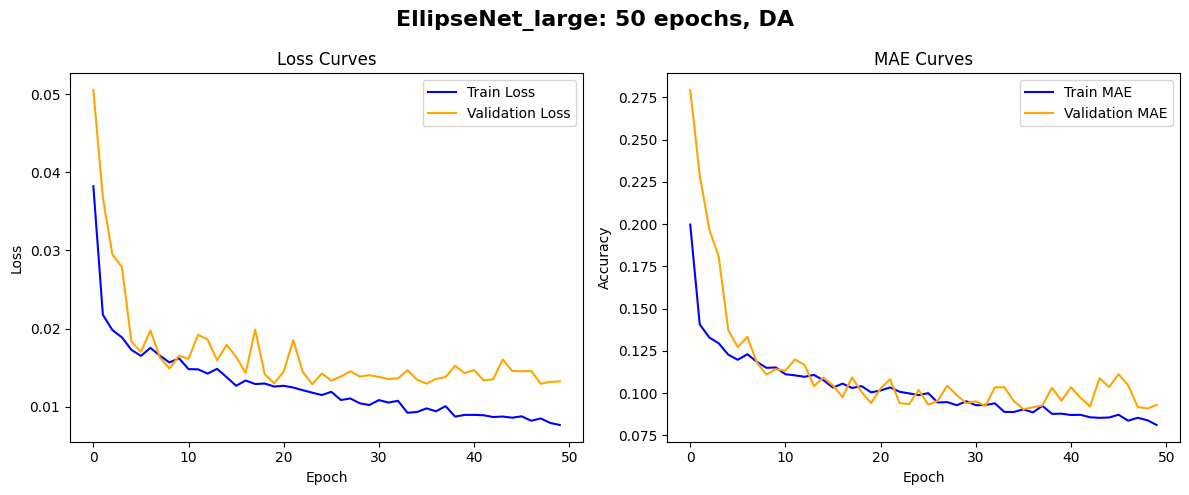

In [ ]:
plot_train_vs_val_loss_mae(losses_list, "EllipseNet_large: 50 epochs, DA")

Ground Truth Parameters: 117.88153839111328 - 124.35214233398438 - 222.23643493652344 - 181.66949462890625 - 92.24840328309823
Predicted Parameters: 119.46902465820312 - 111.54277038574219 - 179.05844116210938 - 131.9875030517578 - 94.32171973246216


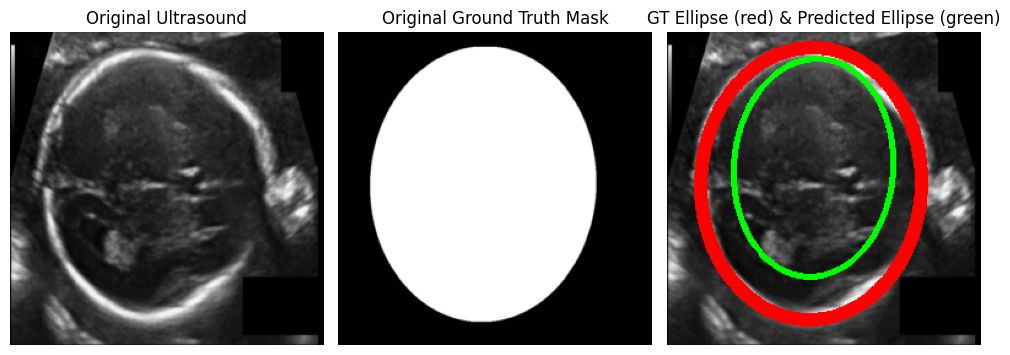

Ground Truth Parameters: 87.68807220458984 - 124.07749938964844 - 178.45668029785156 - 132.2257537841797 - 98.45453856798693
Predicted Parameters: 116.6313705444336 - 108.65605163574219 - 152.89724731445312 - 119.39237213134766 - 97.29807595331788


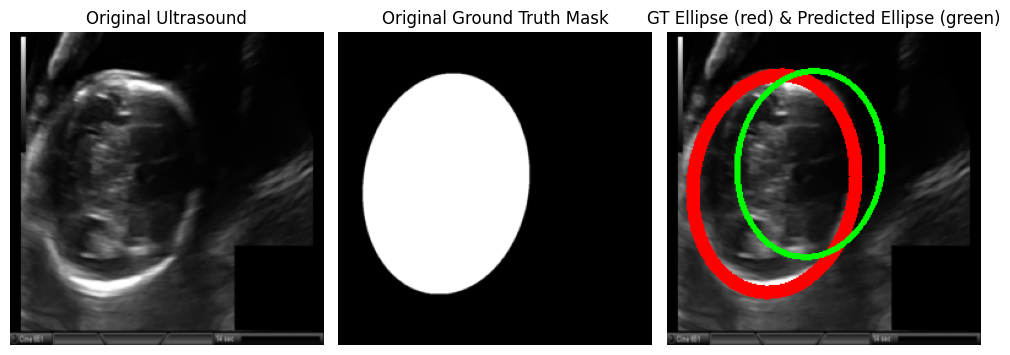

Ground Truth Parameters: 107.97664642333984 - 110.05777740478516 - 183.15489196777344 - 145.37998962402344 - 97.08605584029087
Predicted Parameters: 117.301513671875 - 143.88204956054688 - 151.38870239257812 - 112.29219818115234 - 93.16341554607291


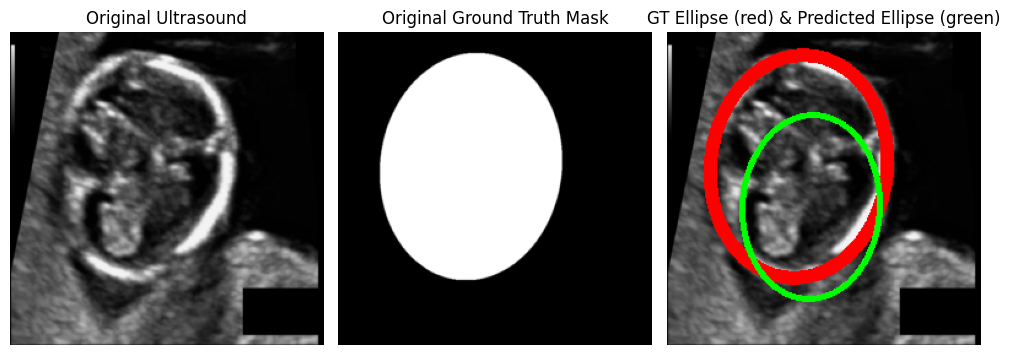

Ground Truth Parameters: 131.4173126220703 - 142.55389404296875 - 129.89108276367188 - 85.60595703125 - 103.56819904070983
Predicted Parameters: 119.46991729736328 - 123.7364501953125 - 174.8770294189453 - 131.7696990966797 - 92.03783635086947


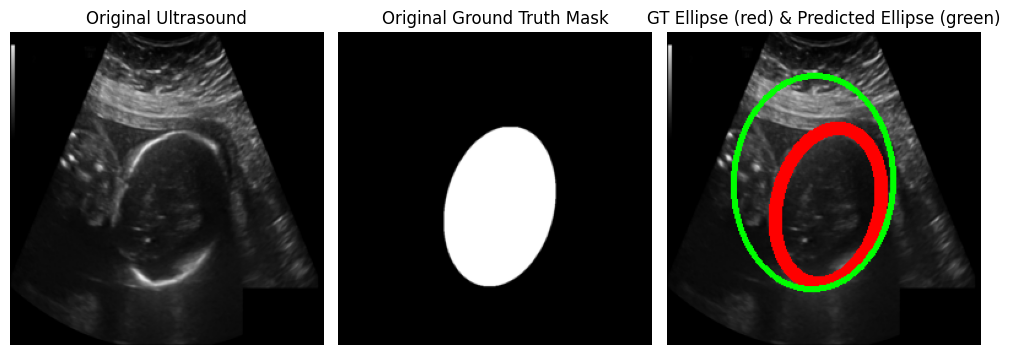

Ground Truth Parameters: 126.79757690429688 - 150.85430908203125 - 168.1717071533203 - 138.79095458984375 - 119.99759079862604
Predicted Parameters: 114.42378997802734 - 125.82273864746094 - 176.6617889404297 - 137.40017700195312 - 91.05830262064629


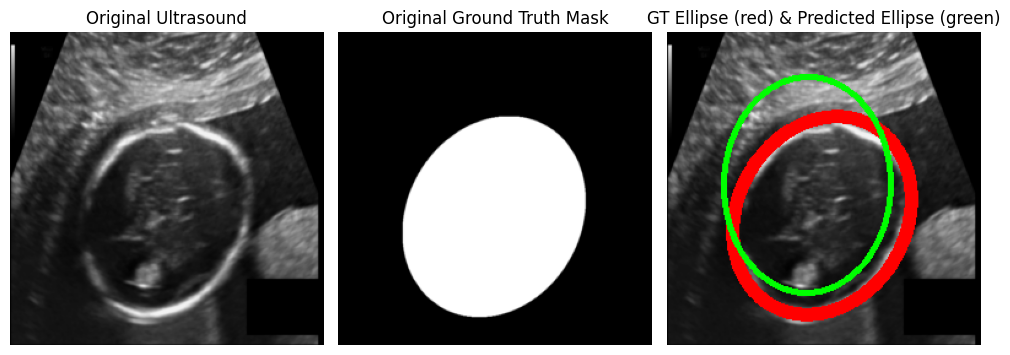

In [ ]:
model_eval = EllipseNet_large()
model_path = os.path.join(RESULTS_DIR, "large_50epochs_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)

plot_predictions_vs_gt(model_eval, test_loader)

# Metric Evaluation

In [ ]:
def IoU(gt_mask, pred_labels):
  xc, yc, dmax, dmin, theta = denormalize_ellipse_parameters(pred_labels, 256, 256)
  theta += 90
  pred_mask = np.zeros((256,256), dtype=np.uint8)
  cv2.ellipse(
      pred_mask,
      (int(xc), int(yc)),
      (int(dmax / 2), int(dmin / 2)), # OpenCV expects half-lengths (radii)
      int(theta),
      0, 360,                         # Draw a full 360-degree ellipse
      (255, 255, 255),                # Color: white
      -1                              # Thickness of the line in pixels, -1 to fill
  )
  mask1 = gt_mask.astype(bool)
  mask2 = pred_mask.astype(bool)

  intersection = np.logical_and(mask1, mask2).sum()
  union = np.logical_or(mask1, mask2).sum()

  iou =  intersection / union if union > 0 else 0.0
  return iou

In [ ]:
def val_step_with_iou(model: nn.Module,
                      dataloader: torch.utils.data.DataLoader,
                      criterion: nn.Module,
                      device: torch.device):

    model.eval()
    model.to(device)

    total_loss = 0.0
    total_mae = 0.0
    total_iou = 0.0
    total_samples = 0

    with torch.inference_mode():
        for images, labels, gt_masks in dataloader:

            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)

            # -------------------
            # Loss + MAE
            # -------------------
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size

            mae = torch.abs(outputs - labels).mean(dim=1)  # per sample MAE
            total_mae += mae.sum().item()

            # -------------------
            # IoU computation
            # -------------------
            for i in range(batch_size):

                gt_mask_np = gt_masks[i].squeeze().cpu().numpy()

                pred_labels_np = outputs[i].cpu().numpy()

                iou = IoU(gt_mask_np, pred_labels_np)

                total_iou += iou

            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_mae = total_mae / total_samples
    avg_iou = total_iou / total_samples

    return avg_loss, avg_mae, avg_iou

In [ ]:
model_names = ["train_classifier_only_model.pt",
               "moderate_ft_model.pt",
               "aggressive_ft_model.pt",
               "aggressive_ft_da_model.pt",]

for name in model_names:
  # Load the trained model
  model_eval = EllipseNet()
  model_path = os.path.join(RESULTS_DIR, name)
  state_dict = torch.load(model_path, map_location=device)
  model_eval.load_state_dict(state_dict)
  model_eval = model_eval.to(device)
  model_eval.eval() # avoid training

  criterion = nn.SmoothL1Loss()

  # Test it with images he has not seen yet:
  avg_test_loss, avg_test_mae, avg_test_iou = val_step_with_iou(
      model=model_eval,
      dataloader=test_loader,
      criterion=criterion,
      device=device
  )

  print(f"--- {name}'s performance on test set ---")
  print(f"Average Loss: {avg_test_loss:.4f}")
  print(f"Average MAE: {avg_test_mae:.2f}")
  print(f"Average Iou: {avg_test_iou:.4f}")
  print("----------------------------------------")



--- train_classifier_only_model.pt's performance on test set ---
Average Loss: 0.0202
Average MAE: 0.14
Average Iou: 0.4533
----------------------------------------
--- moderate_ft_model.pt's performance on test set ---
Average Loss: 0.0241
Average MAE: 0.14
Average Iou: 0.5118
----------------------------------------
--- aggressive_ft_model.pt's performance on test set ---
Average Loss: 0.0245
Average MAE: 0.14
Average Iou: 0.4861
----------------------------------------
--- aggressive_ft_da_model.pt's performance on test set ---
Average Loss: 0.0193
Average MAE: 0.13
Average Iou: 0.5696
----------------------------------------


In [ ]:
# Load the trained model
model_eval = EllipseNet_large()
model_path = os.path.join(RESULTS_DIR, "large_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae, avg_test_iou = val_step_with_iou(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"--- large_da_model's performance on test set ---")
print(f"Average Loss: {avg_test_loss:.4f}")
print(f"Average MAE: {avg_test_mae:.2f}")
print(f"Average Iou: {avg_test_iou:.4f}")
print("----------------------------------------")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 93.3MB/s]


--- large_da_model's performance on test set ---
Average Loss: 0.0155
Average MAE: 0.11
Average Iou: 0.6309
----------------------------------------


In [ ]:
# Load the trained model
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "small_50epochs_da_model.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)
model_eval.eval() # avoid training

criterion = nn.SmoothL1Loss()

# Test it with images he has not seen yet:
avg_test_loss, avg_test_mae, avg_test_iou = val_step_with_iou(
    model=model_eval,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"--- small_50epochs_da_model's performance on test set ---")
print(f"Average Loss: {avg_test_loss:.4f}")
print(f"Average MAE: {avg_test_mae:.2f}")
print(f"Average Iou: {avg_test_iou:.4f}")
print("----------------------------------------")

--- small_50epochs_da_model's performance on test set ---
Average Loss: 0.0134
Average MAE: 0.09
Average Iou: 0.6960
----------------------------------------


# Training from Scratch

In [20]:
model = EllipseNet()

# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier
for param in model.backbone.classifier.parameters():
  param.requires_grad = True

# unfreeze first convolution blocks
for param in model.backbone.features[:6].parameters():
  param.requires_grad = True

# Define the loss function
criterion = nn.SmoothL1Loss()

# Optimizer with different learning rates for the classifier and last conv. blocks
optimizer = optim.Adam([
    {
        "params": model.backbone.features[-2:].parameters(),
        "lr": 1e-4
    },
    {
        "params": model.backbone.classifier.parameters(),
        "lr": 1e-3
    }
])

model = model.to(device)

print("--- Training first layers with data augmentation ---")

losses_list = train(model, train_loader_da, val_loader, criterion, optimizer, device=device, num_epochs=25, model_name='train_from_scratch.pt',  results_path=RESULTS_DIR)


--- Training first layers with data augmentation ---
Epoch 1
Train Loss: 0.03640 | Train MAE: 0.19722 | Val Loss: 0.02281 | Val MAE: 0.15761 | Time: 1m 0.06s

Epoch 2
Train Loss: 0.02146 | Train MAE: 0.14116 | Val Loss: 0.01646 | Val MAE: 0.12044 | Time: 0m 40.09s

Epoch 3
Train Loss: 0.02168 | Train MAE: 0.13844 | Val Loss: 0.02481 | Val MAE: 0.14299 | Time: 0m 34.90s

Epoch 4
Train Loss: 0.02039 | Train MAE: 0.13365 | Val Loss: 0.02109 | Val MAE: 0.13864 | Time: 0m 34.40s

Epoch 5
Train Loss: 0.01976 | Train MAE: 0.12835 | Val Loss: 0.02923 | Val MAE: 0.14872 | Time: 0m 35.22s

Epoch 6
Train Loss: 0.01880 | Train MAE: 0.12608 | Val Loss: 0.01988 | Val MAE: 0.12122 | Time: 0m 34.61s

Epoch 7
Train Loss: 0.02050 | Train MAE: 0.13016 | Val Loss: 0.02027 | Val MAE: 0.12478 | Time: 0m 34.32s

Epoch 8
Train Loss: 0.01897 | Train MAE: 0.12418 | Val Loss: 0.01610 | Val MAE: 0.11066 | Time: 0m 35.38s

Epoch 9
Train Loss: 0.01947 | Train MAE: 0.12736 | Val Loss: 0.01871 | Val MAE: 0.11930 | Ti

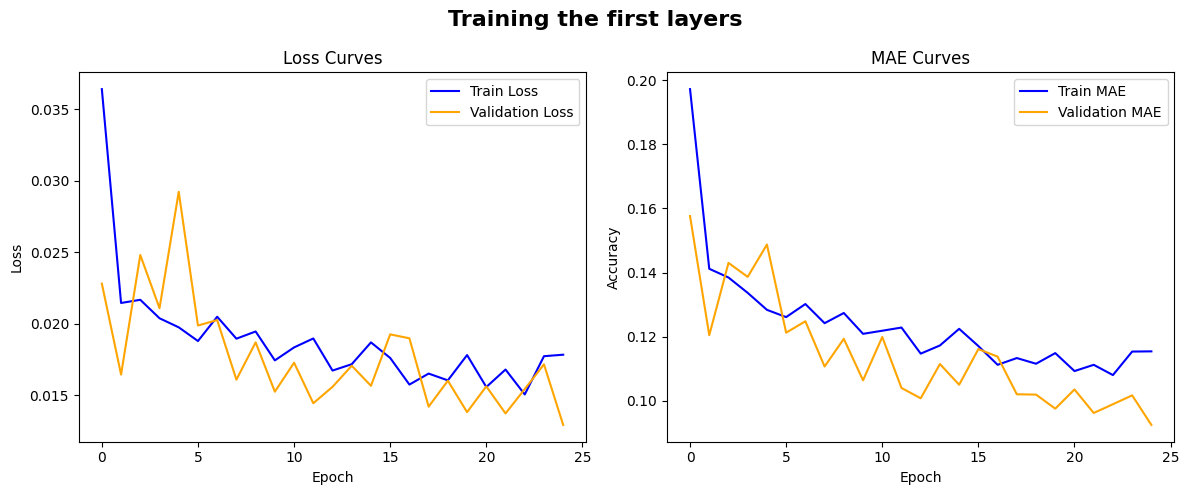

In [21]:
plot_train_vs_val_loss_mae(losses_list, "Training the first layers")

Ground Truth Parameters: 114.32572937011719 - 128.51779174804688 - 180.96646118164062 - 150.02662658691406 - 267.4982299180805
Predicted Parameters: 123.89559936523438 - 126.87770080566406 - 165.02035522460938 - 144.3828887939453 - 267.88970460850265


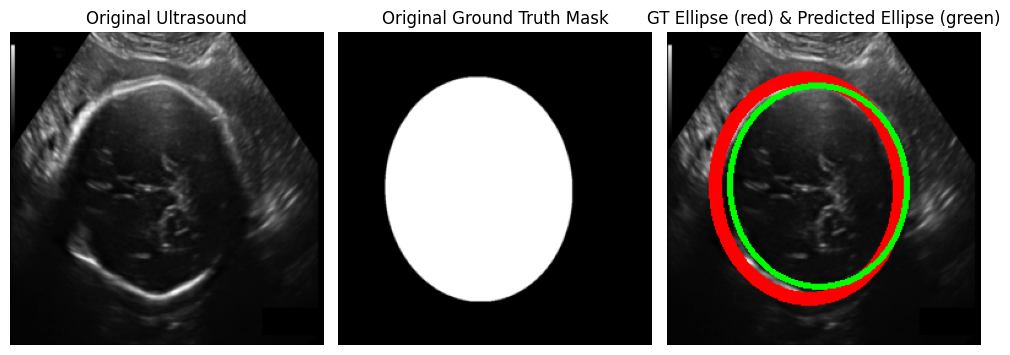

Ground Truth Parameters: 111.35035705566406 - 124.04667663574219 - 186.49282836914062 - 156.67015075683594 - 267.67912304937005
Predicted Parameters: 130.4441680908203 - 128.86268615722656 - 149.54281616210938 - 133.89720153808594 - 267.76193455632506


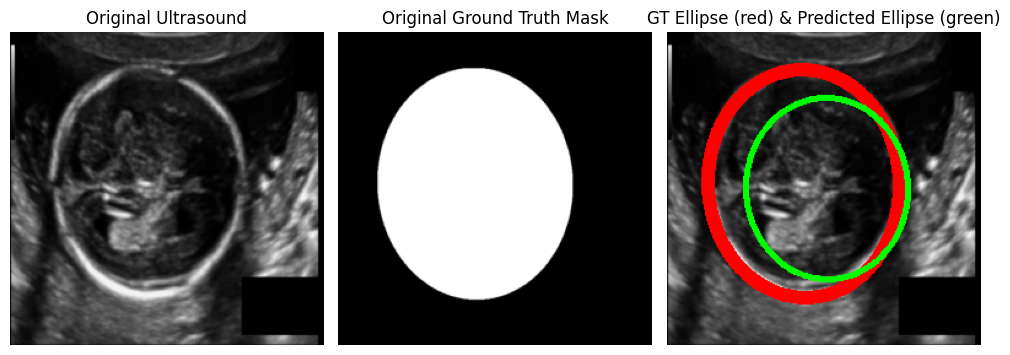

Ground Truth Parameters: 128.05612182617188 - 117.2926254272461 - 112.25932312011719 - 77.54890441894531 - 258.2761075291168
Predicted Parameters: 139.72216796875 - 136.68545532226562 - 170.6617431640625 - 151.613037109375 - 269.50860307467576


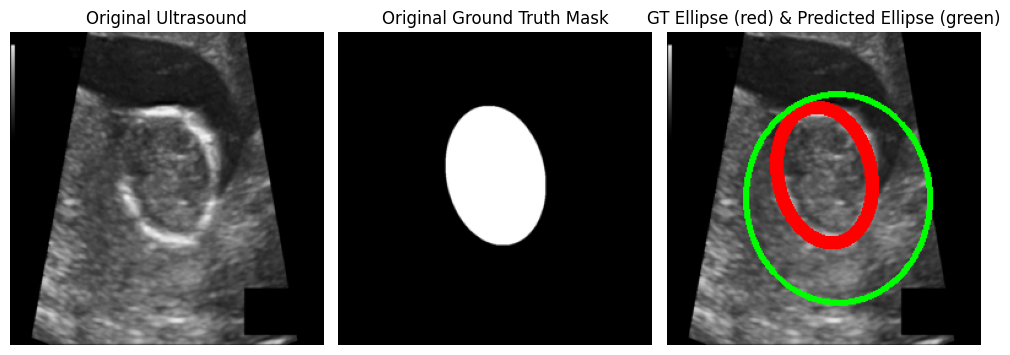

Ground Truth Parameters: 126.34540557861328 - 117.10679626464844 - 178.82061767578125 - 164.27203369140625 - 265.62631230592007
Predicted Parameters: 138.05197143554688 - 133.8262481689453 - 177.09820556640625 - 141.18687438964844 - 268.76415955842015


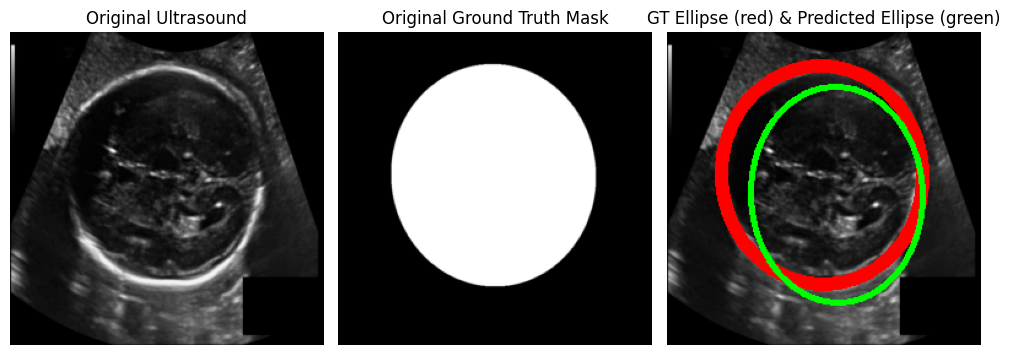

Ground Truth Parameters: 149.97142028808594 - 121.12220001220703 - 153.6036834716797 - 130.661865234375 - 250.87879979601965
Predicted Parameters: 140.5941162109375 - 127.89407348632812 - 181.10415649414062 - 149.90162658691406 - 90.77065366231697


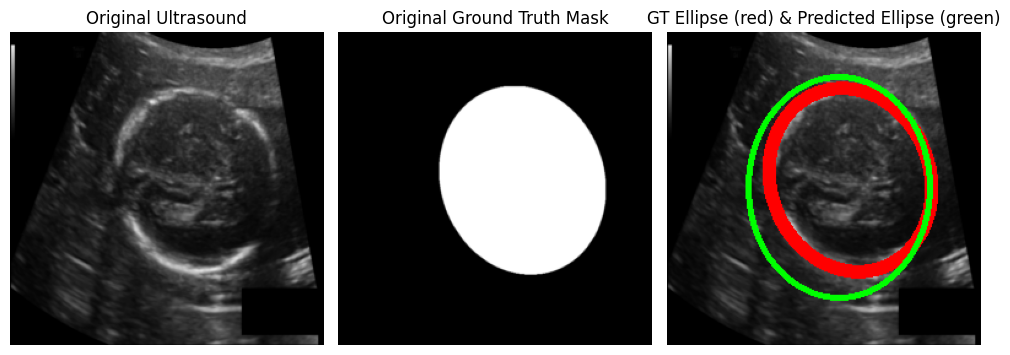

In [22]:
model_eval = EllipseNet()
model_path = os.path.join(RESULTS_DIR, "train_from_scratch.pt")
state_dict = torch.load(model_path, map_location=device)
model_eval.load_state_dict(state_dict)
model_eval = model_eval.to(device)

plot_predictions_vs_gt(model_eval, test_loader)

# Count trainable Parameters

In [16]:
!pip install torchinfo
from torchinfo import summary

In [19]:
model = EllipseNet()

# freeze EVERYTHING
for param in model.parameters():
  param.requires_grad = False

# unfreeze classifier only
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

# unfreeze some last conv. blocks
for param in model.backbone.features[:6].parameters():
    param.requires_grad = True

summary(model, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                                  Output Shape              Param #
EllipseNet                                              [1, 6]                    --
├─MobileNetV3: 1-1                                      [1, 6]                    --
│    └─Sequential: 2-1                                  [1, 576, 8, 8]            --
│    │    └─Conv2dNormActivation: 3-1                   [1, 16, 128, 128]         464
│    │    └─InvertedResidual: 3-2                       [1, 16, 64, 64]           744
│    │    └─InvertedResidual: 3-3                       [1, 24, 32, 32]           3,864
│    │    └─InvertedResidual: 3-4                       [1, 24, 32, 32]           5,416
│    │    └─InvertedResidual: 3-5                       [1, 40, 16, 16]           13,736
│    │    └─InvertedResidual: 3-6                       [1, 40, 16, 16]           57,264
│    │    └─InvertedResidual: 3-7                       [1, 40, 16, 16]           (57,264)
│    │    └─InvertedResidual: 3-8     

# **Number of Parameters in each of our experiments**
**MobileNetV3-Small**

Total params: 1,001,638

Only classifier
Trainable params: 74,630

Last 2 layers and classifier
Trainable params: 425,174

Last 6 layers and classifier
Trainable params: 862,886

Last 4 layers and classifier
Trainable params: 811,118

**MobileNetV3-Large**
Total params: 3,095,734

Last 6 layers and classifier
Trainable params: 2,903,790
